# Install and import

In [ ]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.8 MB/s eta 0:00:00


In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
!wc -l /content/UNSW-NB15_1.csv

700001 /content/UNSW-NB15_1.csv


In [ ]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve


import umap.umap_ as umap

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from torch.optim.lr_scheduler import ReduceLROnPlateau


# Data - 5elem

## UNSW1

In [ ]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]


# # Filter connections from the first 110 minutes (that's where there are malicios connections)
# # And select columns of interest
# start_time = data_unsw1['stime'].min()
# end_time = start_time + timedelta(minutes=110)

# unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# # Drop rows with NaN values (i.e., missing ports)
# unsw1_sub.replace('-', pd.NA, inplace=True)
# unsw1 = unsw1_sub.dropna()

In [ ]:
len(unsw1)

133769

In [ ]:
data_unsw1.duplicated().sum()

59213

In [ ]:
unsw1_sub_NOdrop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']]
unsw1_sub_NOdrop.duplicated().sum()

19

In [ ]:
unsw1_sub_drop = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()
unsw1_sub_drop.duplicated().sum()

0

In [ ]:
unsw1.duplicated().sum()

0

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Seleccionar las características a normalizar
# features_to_normalize = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

# # Crear un objeto MinMaxScaler
# scaler = MinMaxScaler()

# # Ajustar y transformar las características
# unsw1[features_to_normalize] = scaler.fit_transform(unsw1[features_to_normalize])

# # Verificar resultados
# print(unsw1[features_to_normalize].describe())

Text(0, 0.5, 'Frecuencia')

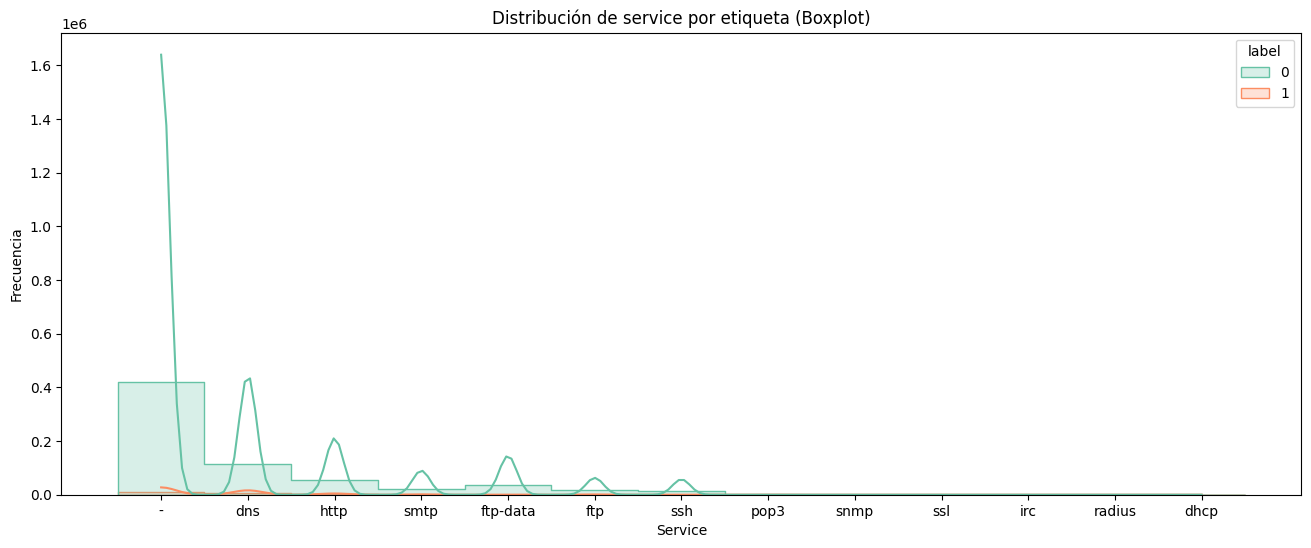

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.histplot(data=data_unsw1, x='service', hue='label', kde=True, palette='Set2', element='step')
plt.title(f'Distribución de service por etiqueta (Boxplot)')
plt.xlabel('Service')
plt.ylabel('Frecuencia')

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


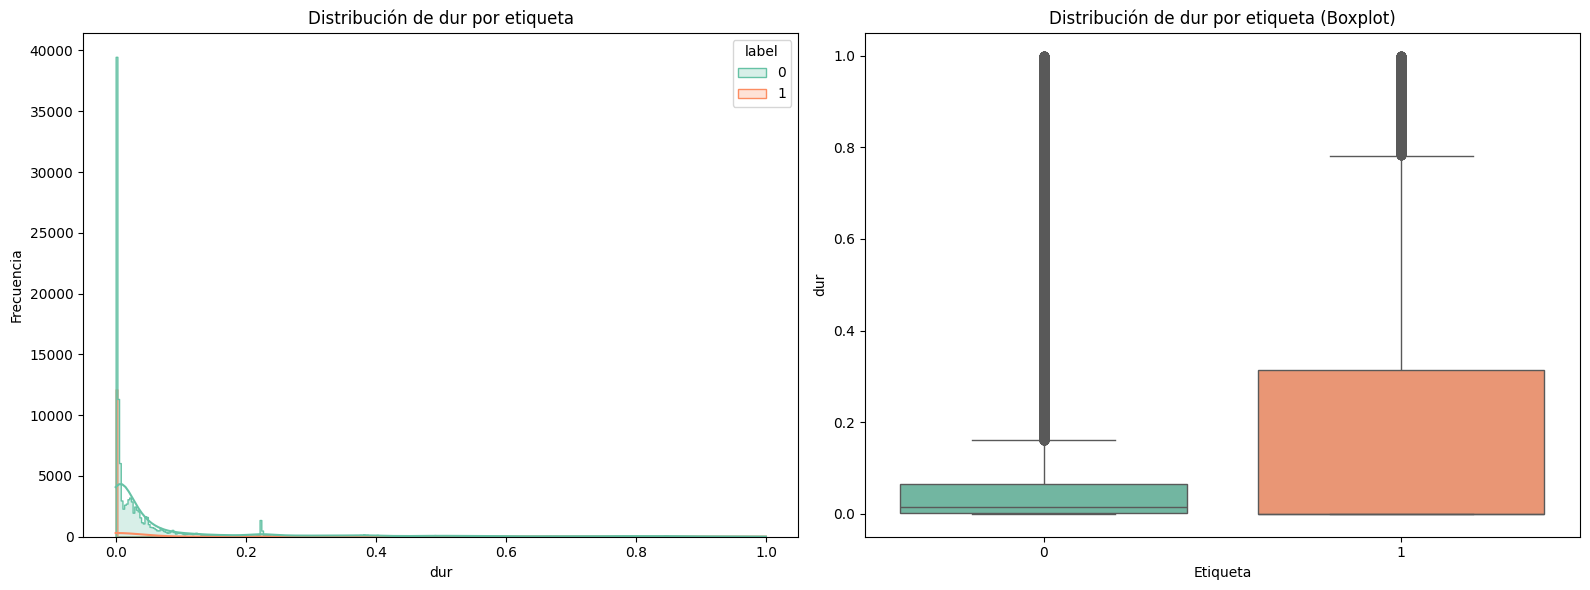

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


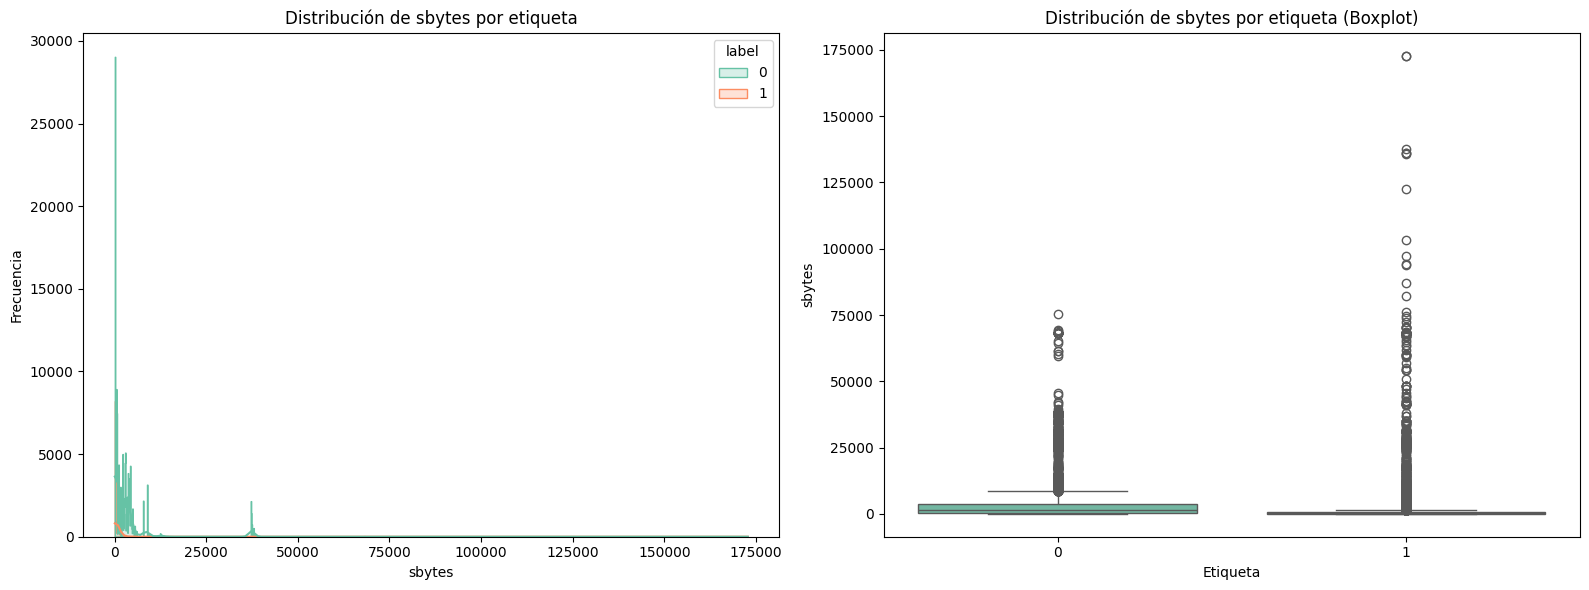

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


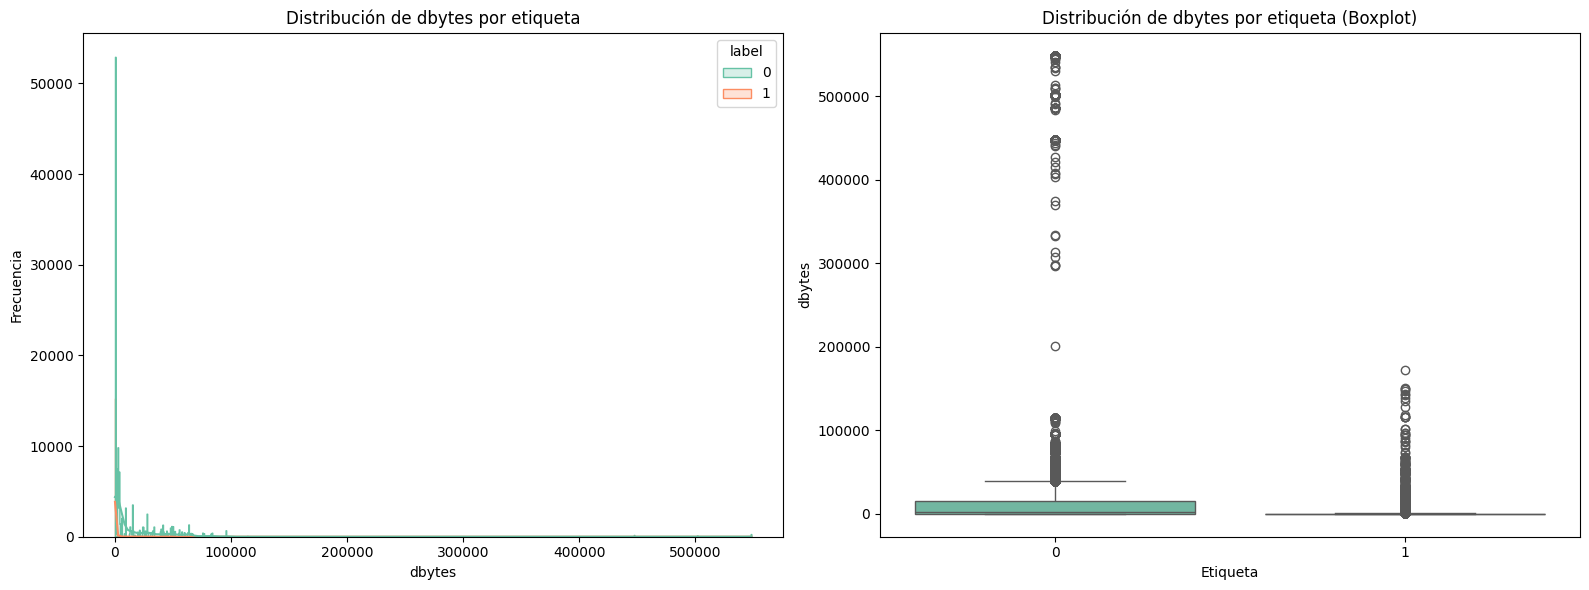

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


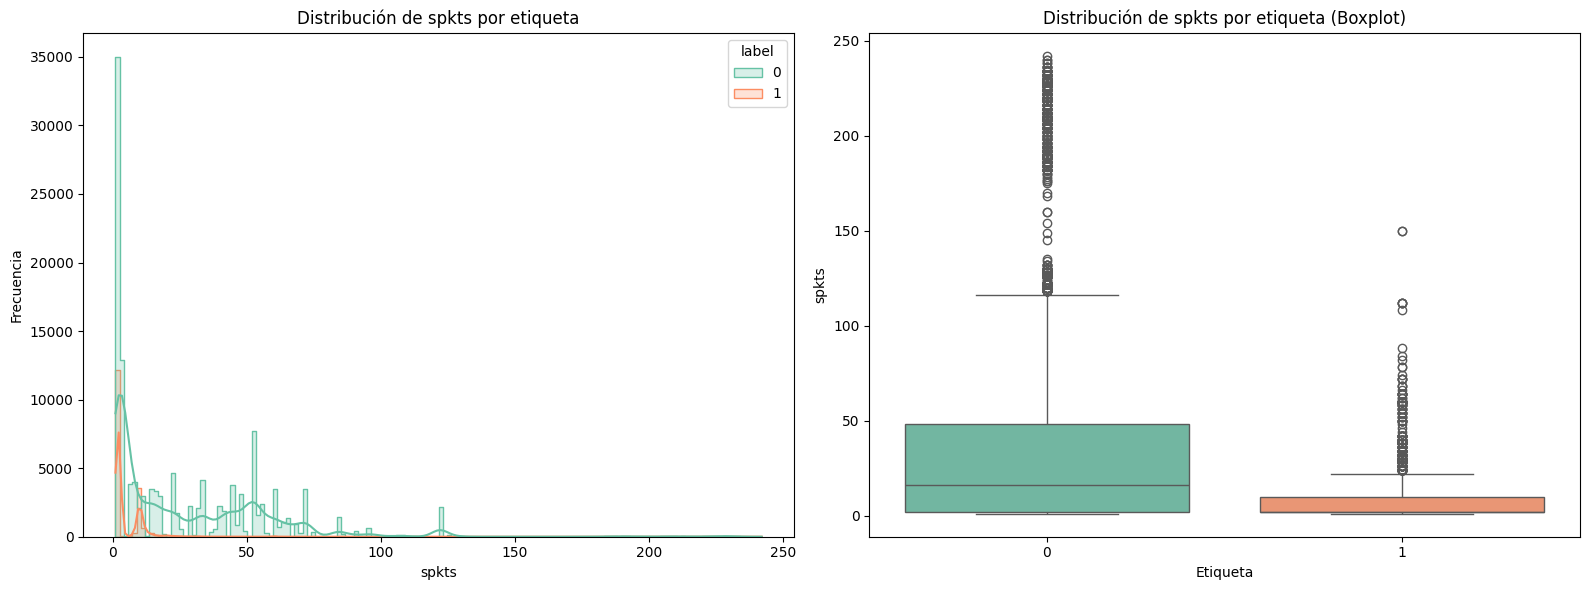

<ipython-input-60-df355e9cd2bb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')


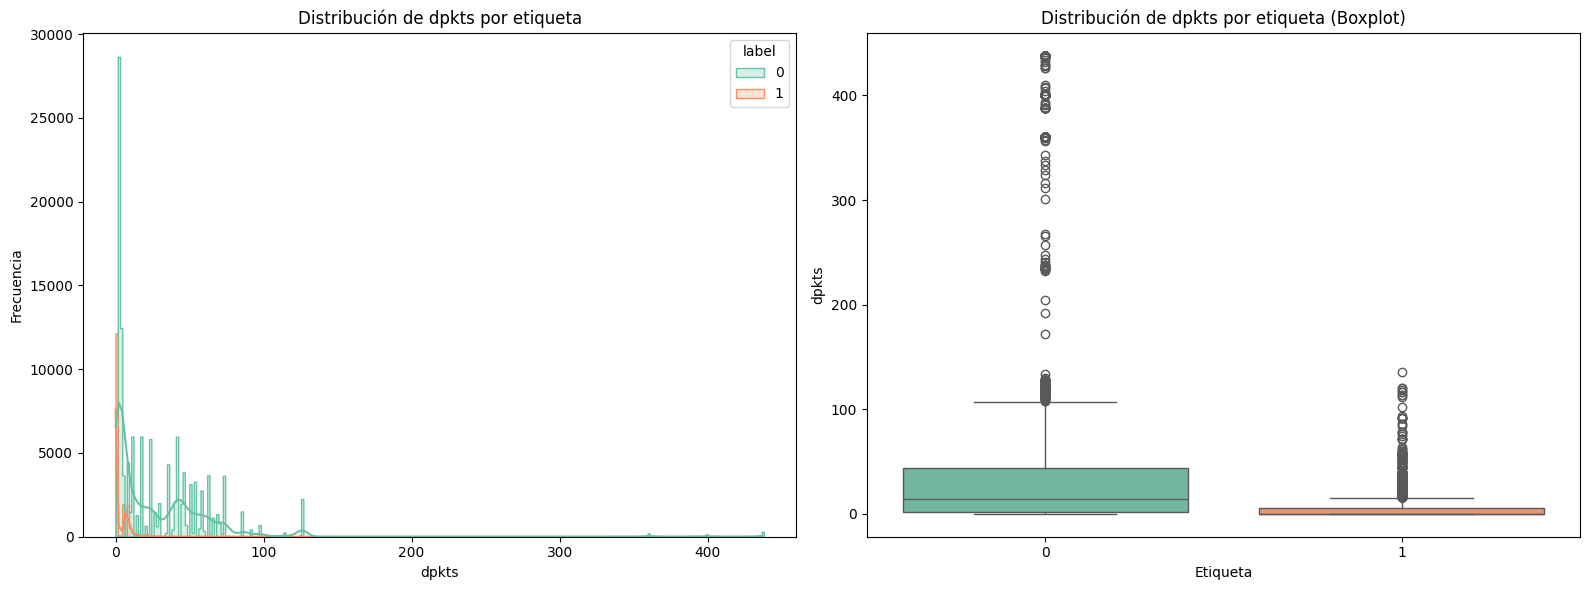

Resumen estadístico de características por etiqueta:
label                     0              1
dur    count  129638.000000   17583.000000
       mean        0.095572       0.175556
       std         0.191167       0.292284
       min         0.000001       0.000001
       25%         0.001133       0.000006
       50%         0.015694       0.000011
       75%         0.065296       0.313004
       max         0.999911       0.999796
sbytes count  129638.000000   17583.000000
       mean     3707.852713    1205.460957
       std      7646.479198    6260.903199
       min        52.000000      60.000000
       25%       264.000000     114.000000
       50%      1540.000000     200.000000
       75%      3614.000000     662.000000
       max     75496.000000  172777.000000
dbytes count  129638.000000   17583.000000
       mean    15315.718192     925.854291
       std     41318.436394    6325.192980
       min         0.000000       0.000000
       25%       178.000000       0.000000
 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para análisis
snapshot_data = unsw1.copy()  # Asegúrate de usar el conjunto preprocesado `unsw1`

# Seleccionar columnas relevantes
features_to_plot = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']  # Características más importantes
labels = snapshot_data['label']  # Etiqueta

# Crear histogramas y boxplots por característica y etiqueta
for feature in features_to_plot:
    plt.figure(figsize=(16, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data=snapshot_data, x=feature, hue='label', kde=True, palette='Set2', element='step')
    plt.title(f'Distribución de {feature} por etiqueta')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=snapshot_data, x='label', y=feature, palette='Set2')
    plt.title(f'Distribución de {feature} por etiqueta (Boxplot)')
    plt.xlabel('Etiqueta')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# Resumen estadístico
print("Resumen estadístico de características por etiqueta:")
summary_stats = snapshot_data.groupby('label')[features_to_plot].describe().transpose()
print(summary_stats)


### Option 1: Nodes = (ip, port)

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3) # Snapshots every 3 minutes

start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()  # Limpia espacios en 'ip'
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()  # Asegura que 'port' es cadena
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport']).agg({        # AGREGO puerto, pero no se como considerar el protocolo
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot

#graph_snapshots = {i: Data(x=node_features_pad, edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}
torch_geo_graphs_unsw1 = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

### Option 2: Nodes = (ip,port,proto) - Features de los edges

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    # src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
    #     'spkts': 'mean',
    #     'sbytes': 'mean'
    # }).reset_index()
    # src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    # src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    #     'dpkts': 'mean',
    #     'dbytes': 'mean'
    # }).reset_index()
    # dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    # dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    # nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    # nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    # nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)

    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'sbytes': 'mean',
        'dbytes': 'mean',
        'spkts': 'mean',
        'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    #edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    #node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[4451, 1], edge_index=[2, 3279], edge_attr=[3279, 5], y=[3279]),
 1: Data(x=[4843, 1], edge_index=[2, 3532], edge_attr=[3532, 5], y=[3532]),
 2: Data(x=[4764, 1], edge_index=[2, 3570], edge_attr=[3570, 5], y=[3570]),
 3: Data(x=[5494, 1], edge_index=[2, 4187], edge_attr=[4187, 5], y=[4187]),
 4: Data(x=[5688, 1], edge_index=[2, 4376], edge_attr=[4376, 5], y=[4376]),
 5: Data(x=[4931, 1], edge_index=[2, 3554], edge_attr=[3554, 5], y=[3554]),
 6: Data(x=[5456, 1], edge_index=[2, 3971], edge_attr=[3971, 5], y=[3971]),
 7: Data(x=[5042, 1], edge_index=[2, 3605], edge_attr=[3605, 5], y=[3605]),
 8: Data(x=[4898, 1], edge_index=[2, 3414], edge_attr=[3414, 5], y=[3414]),
 9: Data(x=[4794, 1], edge_index=[2, 3300], edge_attr=[3300, 5], y=[3300]),
 10: Data(x=[4771, 1], edge_index=[2, 3333], edge_attr=[3333, 5], y=[3333]),
 11: Data(x=[4908, 1], edge_index=[2, 3379], edge_attr=[3379, 5], y=[3379]),
 12: Data(x=[5495, 1], edge_index=[2, 3664], edge_attr=[3664, 5], y=[3664]),
 13: Data

### Option 2': Nodes = (ip, port, proto) - Features de los nodos

In [ ]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
div_prop=0
for i in range(len(torch_geo_graphs_unsw1_proto)):
  sum_norm=0
  sum_bot=0
  for j in range(len(torch_geo_graphs_unsw1_proto[i].y)):
    if torch_geo_graphs_unsw1_proto[i].y[j]==0:
      sum_norm+=1
    else:
      sum_bot+=1
  div_prop+= (sum_norm/sum_bot)
  print(i,sum_norm,sum_bot,sum_norm/sum_bot)

print(div_prop/36)

0 3117 162 19.24074074074074
1 3235 297 10.892255892255893
2 3386 184 18.402173913043477
3 4119 68 60.5735294117647
4 4247 129 32.92248062015504
5 3371 183 18.420765027322403
6 3795 176 21.5625
7 3343 262 12.759541984732824
8 3239 175 18.50857142857143
9 3093 207 14.942028985507246
10 3149 184 17.11413043478261
11 3142 237 13.257383966244726
12 3443 221 15.57918552036199
13 3422 210 16.295238095238094
14 3621 190 19.057894736842105
15 3558 197 18.060913705583758
16 3362 170 19.776470588235295
17 3406 177 19.242937853107346
18 3233 339 9.536873156342184
19 3239 178 18.196629213483146
20 3191 236 13.521186440677965
21 3300 198 16.666666666666668
22 3337 168 19.863095238095237
23 3311 169 19.59171597633136
24 3300 178 18.53932584269663
25 3403 183 18.595628415300546
26 3087 226 13.65929203539823
27 3133 205 15.282926829268293
28 3174 187 16.97326203208556
29 3198 210 15.228571428571428
30 3377 176 19.1875
31 3758 132 28.46969696969697
32 3288 103 31.92233009708738
33 3318 173 19.179190751

In [ ]:
# Esta comparacion no es justa, porque los nodos y edges cambian de un snapshot a otro

pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[1].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

#### Breve exploracion del preprocesamiento

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

node_features_orig = []
pair_to_index_list = []
src_features_list = []
dst_features_list = []
edge_attr_list = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features_orig = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')

    nodes_features = nodes_features_orig[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    node_features_orig.append(nodes_features_orig)
    pair_to_index_list.append(pair_to_index)
    src_features_list.append(src_features)
    dst_features_list.append(dst_features)
    edge_attr_list.append(edge_attr)


    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto[0]

Data(x=[4451, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279])

In [ ]:
inverted_dict = {v: k for k, v in pair_to_index_list[0].items()}

In [ ]:
for i in range(len(labels[0])):
  srcip,sport,proto = inverted_dict[int(edge_indices[0][0,i])].split(',')
  dstip,dsport,proto1 = inverted_dict[int(edge_indices[0][1,i])].split(',')
  assert proto==proto1, 'not same protocol'
  if len(unsw1[(unsw1['srcip']==srcip) & (unsw1['sport']==sport) & (unsw1['dstip']==dstip) & (unsw1['dsport']==dsport)])>1:
    print(i)

692
2389
2446
2508


In [ ]:
edge_indices[0][:,2389]

tensor([3561,  619])

In [ ]:
print(inverted_dict[3561])
print(inverted_dict[619])

59.166.0.7,1133,udp
149.171.126.4,53,udp


In [ ]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [ ]:
unsw1[(unsw1['dstip']=='59.166.0.7') & (unsw1['dsport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label


In [ ]:
node_features_orig[0].iloc[3561,:]

,3561
src_pairs,"59.166.0.7,1133,udp"
srcip,59.166.0.7
sport,1133
proto_x,udp
spkts,2.0
sbytes,130.0
dst_pairs,"59.166.0.7,1133,udp"
dstip,0
dsport,0
proto_y,0


In [ ]:
node_features[0][3561,:]

tensor([  2., 130.,   0.,   0.])

In [ ]:
edge_attr_list[0].iloc[2389,:]

,2389
srcip,59.166.0.7
sport,1133
proto,udp
dstip,149.171.126.4
dsport,53
dur,0.000893
label,0
src_pairs,"59.166.0.7,1133,udp"
dst_pairs,"149.171.126.4,53,udp"


In [ ]:
edge_features[0][2389]

tensor([0.0009])

In [ ]:
aux = unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

aux.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
}).reset_index()

,srcip,sport,proto,spkts,sbytes
0,59.166.0.7,1133,udp,2.0,138.0


In [ ]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,spkts,dpkts,stime,ltime,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,0.000893,130,162,2,2,2015-01-22 11:52:42,2015-01-22 11:52:42,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,0.001065,146,178,2,2,2015-01-22 13:18:00,2015-01-22 13:18:00,0


In [ ]:
pair_to_index_list[0]['59.166.0.7,1133,udp']

3561

In [ ]:
labels[0][2389]

tensor(0)

#### Armando pair_to_index considerando todos los nodos del grafo, no por snapshot

El tensor `x` tiene shape [172471, 4] para todos los snapshots, porque se completan con 0s las features de aquellos nodos que no aparecen en el snapshot. Esto podría causar ruido... demasiados ceros...

Quizás se podrían usar máscaras.

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot

src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'dpkts', 'dbytes']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        #'sbytes': 'mean',
        #'dbytes': 'mean',
        #'spkts': 'mean',
        #'dpkts': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    #edge_features_tensor = torch.tensor(edge_attr[['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']].values, dtype=torch.float)
    edge_features_tensor = torch.tensor(edge_attr[['dur']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto

{0: Data(x=[172471, 4], edge_index=[2, 3279], edge_attr=[3279, 1], y=[3279]),
 1: Data(x=[172471, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532]),
 2: Data(x=[172471, 4], edge_index=[2, 3570], edge_attr=[3570, 1], y=[3570]),
 3: Data(x=[172471, 4], edge_index=[2, 4187], edge_attr=[4187, 1], y=[4187]),
 4: Data(x=[172471, 4], edge_index=[2, 4376], edge_attr=[4376, 1], y=[4376]),
 5: Data(x=[172471, 4], edge_index=[2, 3554], edge_attr=[3554, 1], y=[3554]),
 6: Data(x=[172471, 4], edge_index=[2, 3971], edge_attr=[3971, 1], y=[3971]),
 7: Data(x=[172471, 4], edge_index=[2, 3605], edge_attr=[3605, 1], y=[3605]),
 8: Data(x=[172471, 4], edge_index=[2, 3414], edge_attr=[3414, 1], y=[3414]),
 9: Data(x=[172471, 4], edge_index=[2, 3300], edge_attr=[3300, 1], y=[3300]),
 10: Data(x=[172471, 4], edge_index=[2, 3333], edge_attr=[3333, 1], y=[3333]),
 11: Data(x=[172471, 4], edge_index=[2, 3379], edge_attr=[3379, 1], y=[3379]),
 12: Data(x=[172471, 4], edge_index=[2, 3664], edge_attr=[3664

In [ ]:
# Esta comparacion SI es justa, porque usamos los mismos nodos para cada snapshot

pairs1 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[0].edge_index.T.tolist())

for i in range(len(torch_geo_graphs_unsw1_proto)):
  pairs2 = set(tuple(pair) for pair in torch_geo_graphs_unsw1_proto[i].edge_index.T.tolist())
  print(i,len(pairs1.intersection(pairs2)),len(pairs1.intersection(pairs2))/len(torch_geo_graphs_unsw1_proto[i].y))

0 3279 1.0
1 0 0.0
2 0 0.0
3 0 0.0
4 0 0.0
5 0 0.0
6 0 0.0
7 0 0.0
8 0 0.0
9 0 0.0
10 0 0.0
11 0 0.0
12 0 0.0
13 1 0.00027533039647577095
14 0 0.0
15 0 0.0
16 0 0.0
17 0 0.0
18 0 0.0
19 0 0.0
20 0 0.0
21 0 0.0
22 0 0.0
23 1 0.00028735632183908046
24 0 0.0
25 0 0.0
26 0 0.0
27 0 0.0
28 1 0.0002975304968759298
29 1 0.00029342723004694836
30 0 0.0
31 0 0.0
32 0 0.0
33 0 0.0
34 0 0.0
35 0 0.0


### Option 3: more features

In [ ]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
len(unsw1.keys())

25

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot

pair_to_index_list = []
unique_pairs_list = []

while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    pair_to_index_list.append(pair_to_index)
    unique_pairs_list.append(unique_pairs)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto_more

{0: Data(x=[4451, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[4843, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[4764, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[5494, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[5688, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[4931, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[5456, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[5042, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[4898, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[4794, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[4771, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[4908, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[5495, 14], edge_index=[2, 3664], edge_attr=[3664, 3], y=[3664

### Option 4: more features, included nominal

In [ ]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','service','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub['sport'] = unsw1_sub['sport'].replace('-', pd.NA)
unsw1_sub['dsport'] = unsw1_sub['dsport'].replace('-', pd.NA)
unsw1 = unsw1_sub.dropna()

#### Breve exploracion del preprocesamiento

In [ ]:
# EXPLORE PREPROCESS
embedding_nominal_dim = 8

states = list(unsw1['state'].drop_duplicates())
services = list(unsw1['service'].drop_duplicates())

state_embedding = nn.Embedding(num_embeddings=len(states), embedding_dim=embedding_nominal_dim)
service_embedding = nn.Embedding(num_embeddings=len(services), embedding_dim=embedding_nominal_dim)

# Label Encoding
state_encoder = LabelEncoder()
service_encoder = LabelEncoder()
unsw1['state'] = state_encoder.fit_transform(unsw1['state'])
unsw1['service'] = service_encoder.fit_transform(unsw1['service'])

edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

node_features_orig = []
pair_to_index_list = []
src_features_list = []
dst_features_list = []
edge_attr_list = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features_orig = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')

    nodes_features = nodes_features_orig[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'state': 'mean',
        'service': 'mean',
        'label': 'max'
    }).reset_index()

    edge_attr['state'] = edge_attr['state'].apply(lambda x: int(x))
    edge_attr['service'] = edge_attr['service'].apply(lambda x: int(x))

    state_index = torch.tensor(edge_attr['state'].values)  # Correspondiente a 'ACC', 'CON', 'ECR'
    service_index = torch.tensor(edge_attr['service'].values)  # Correspondiente a 'http', 'ssh', 'ftp-data'

    state_emb = state_embedding(state_index).detach()
    service_emb = service_embedding(service_index).detach()

    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_features_tensor = torch.cat([edge_features_tensor, state_emb, service_emb], dim=1)

    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    node_features_orig.append(nodes_features_orig)
    pair_to_index_list.append(pair_to_index)
    src_features_list.append(src_features)
    dst_features_list.append(dst_features)
    edge_attr_list.append(edge_attr)


    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


#torch_geo_graphs_unsw1_proto = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
edge_indices[0]

tensor([[1173, 1174, 1175,  ..., 4448, 4449, 4450],
        [ 280,  239,  279,  ..., 1149,  509,  706]])

In [ ]:
inverted_dict = {v: k for k, v in pair_to_index_list[0].items()}

In [ ]:
for i in range(len(labels[0])):
  srcip,sport,proto = inverted_dict[int(edge_indices[0][0,i])].split(',')
  dstip,dsport,proto1 = inverted_dict[int(edge_indices[0][1,i])].split(',')
  assert proto==proto1, 'not same protocol'
  if len(unsw1[(unsw1['srcip']==srcip) & (unsw1['sport']==sport) & (unsw1['dstip']==dstip) & (unsw1['dsport']==dsport)])>1:
    print(i)

692
2389
2446
2508


In [ ]:
edge_indices[0][:,2389]

tensor([3561,  619])

In [ ]:
print(inverted_dict[3561])
print(inverted_dict[619])

59.166.0.7,1133,udp
149.171.126.4,53,udp


In [ ]:
unsw1[(unsw1['srcip']=='59.166.0.7') & (unsw1['sport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,dpkts,sjit,djit,stime,ltime,sintpkt,dintpkt,synack,ackdat,label
4218,59.166.0.7,1133,149.171.126.4,53,udp,2,0.000893,130,162,31,...,2,0.0,0.0,2015-01-22 11:52:42,2015-01-22 11:52:42,0.004,0.003,0.0,0.0,0
142099,59.166.0.7,1133,149.171.126.4,53,udp,2,0.001065,146,178,31,...,2,0.0,0.0,2015-01-22 13:18:00,2015-01-22 13:18:00,0.010,0.006,0.0,0.0,0


In [ ]:
unsw1[(unsw1['dstip']=='59.166.0.7') & (unsw1['dsport']=='1133') & (unsw1['proto']=='udp')]

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,dpkts,sjit,djit,stime,ltime,sintpkt,dintpkt,synack,ackdat,label


In [ ]:
node_features_orig[0].iloc[3561,:]

,3561
src_pairs,"59.166.0.7,1133,udp"
srcip,59.166.0.7
sport,1133
proto_x,udp
spkts,2.0
sbytes,130.0
sttl,31.0
sloss,0.0
sload,582306.8125
sjit,0.0


In [ ]:
node_features[0][3561,:]

tensor([2.0000e+00, 1.3000e+02, 3.1000e+01, 0.0000e+00, 5.8231e+05, 0.0000e+00,
        4.0000e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00])

In [ ]:
edge_attr_list[0].iloc[2389,:]

,2389
srcip,59.166.0.7
sport,1133
proto,udp
dstip,149.171.126.4
dsport,53
dur,0.000893
synack,0.0
ackdat,0.0
state,2
service,2


In [ ]:
print(state_embedding(torch.tensor(2)).detach())
print(service_embedding(torch.tensor(2)).detach())

tensor([-0.2794,  0.8075, -0.6250,  1.2374,  1.0129,  1.1483, -1.9377, -1.6521])
tensor([-1.6910,  1.2561, -0.0123,  0.1861,  0.1637, -1.2188, -0.1994,  0.7737])


In [ ]:
edge_features[0][2389]

tensor([ 8.9300e-04,  0.0000e+00,  0.0000e+00, -2.7942e-01,  8.0750e-01,
        -6.2499e-01,  1.2374e+00,  1.0129e+00,  1.1483e+00, -1.9377e+00,
        -1.6521e+00, -1.6910e+00,  1.2561e+00, -1.2276e-02,  1.8610e-01,
         1.6371e-01, -1.2188e+00, -1.9942e-01,  7.7365e-01])

#### Final

In [ ]:
embedding_nominal_dim = 8

states = list(unsw1['state'].drop_duplicates())
services = list(unsw1['service'].drop_duplicates())

state_embedding = nn.Embedding(num_embeddings=len(states), embedding_dim=embedding_nominal_dim)
service_embedding = nn.Embedding(num_embeddings=len(services), embedding_dim=embedding_nominal_dim)

# Label Encoding
state_encoder = LabelEncoder()
service_encoder = LabelEncoder()
unsw1['state'] = state_encoder.fit_transform(unsw1['state'])
unsw1['service'] = service_encoder.fit_transform(unsw1['service'])

edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src = snapshot_data[['srcip', 'sport','proto']].copy()
    src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs = pd.concat([src,dst]).drop_duplicates()
    unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'state': 'mean',
        'service': 'mean',
        'label': 'max'
    }).reset_index()

    edge_attr['state'] = edge_attr['state'].apply(lambda x: int(x))
    edge_attr['service'] = edge_attr['service'].apply(lambda x: int(x))

    state_index = torch.tensor(edge_attr['state'].values)  # Correspondiente a 'ACC', 'CON', 'ECR'
    service_index = torch.tensor(edge_attr['service'].values)  # Correspondiente a 'http', 'ssh', 'ftp-data'

    state_emb = state_embedding(state_index).detach()
    service_emb = service_embedding(service_index).detach()

    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_features_tensor = torch.cat([edge_features_tensor, state_emb, service_emb], dim=1)


    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more2 = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto_more2

{0: Data(x=[4451, 14], edge_index=[2, 3279], edge_attr=[3279, 19], y=[3279]),
 1: Data(x=[4843, 14], edge_index=[2, 3532], edge_attr=[3532, 19], y=[3532]),
 2: Data(x=[4764, 14], edge_index=[2, 3570], edge_attr=[3570, 19], y=[3570]),
 3: Data(x=[5494, 14], edge_index=[2, 4187], edge_attr=[4187, 19], y=[4187]),
 4: Data(x=[5688, 14], edge_index=[2, 4376], edge_attr=[4376, 19], y=[4376]),
 5: Data(x=[4931, 14], edge_index=[2, 3554], edge_attr=[3554, 19], y=[3554]),
 6: Data(x=[5456, 14], edge_index=[2, 3971], edge_attr=[3971, 19], y=[3971]),
 7: Data(x=[5042, 14], edge_index=[2, 3605], edge_attr=[3605, 19], y=[3605]),
 8: Data(x=[4898, 14], edge_index=[2, 3414], edge_attr=[3414, 19], y=[3414]),
 9: Data(x=[4794, 14], edge_index=[2, 3300], edge_attr=[3300, 19], y=[3300]),
 10: Data(x=[4771, 14], edge_index=[2, 3333], edge_attr=[3333, 19], y=[3333]),
 11: Data(x=[4908, 14], edge_index=[2, 3379], edge_attr=[3379, 19], y=[3379]),
 12: Data(x=[5495, 14], edge_index=[2, 3664], edge_attr=[3664,

### Option 3 (more features) for RNN - 172471 nodes

Here all snapshots should have the same indices for all nodes: if node 1 is present in snapshot 1 and 5, then it should have the same index in both snapshots.

In [ ]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more_rnn = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw1_proto_more_rnn

{0: Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[172471, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[172471, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[172471, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[172471, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[172471, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[172471, 14], edge_index=[2, 3664], ed

### ~Option 3 (more features) for RNN - masks for nodes~

Here all snapshots should have the same indices for all nodes: if node 1 is present in snapshot 1 and 5, then it should have the same index in both snapshots.

In [ ]:
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
edge_indices = []
edge_indices_local = []
edge_features = []
labels = []
edge_weights = []
node_features = []
unique_pairs_local_list = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()


interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


src = unsw1[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw1[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

    src_local = snapshot_data[['srcip', 'sport','proto']].copy()
    src_local.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    dst_local = snapshot_data[['dstip', 'dsport','proto']].copy()
    dst_local.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    unique_pairs_local = pd.concat([src_local,dst_local]).drop_duplicates()
    unique_pairs_local['ip'] = unique_pairs_local['ip'].str.strip()
    unique_pairs_local['port'] = unique_pairs_local['port'].astype(str).str.strip()
    unique_pairs_local = unique_pairs_local.drop_duplicates(subset=['ip', 'port', 'proto'])

    unique_pairs_local['pair_id'] = unique_pairs_local.groupby(['ip','port','proto']).ngroup()
    unique_pairs_local = unique_pairs_local.sort_values('pair_id').set_index('pair_id').reset_index()
    unique_pairs_local['pairs'] = unique_pairs_local.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    pair_to_index_local = {pair: idx for idx, pair in zip(unique_pairs_local['pair_id'], unique_pairs_local['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()
    edge_index_local = torch.tensor([[pair_to_index_local[src], pair_to_index_local[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_indices_local.append(edge_index_local)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    unique_pairs_local_list.append(unique_pairs_local)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot




torch_geo_graphs_unsw1_proto_more_rnn_local = {i: Data(x=node_features[i], edge_index=edge_indices_local[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
print(edge_indices_local[0][0])
print(edge_indices[0][0])

tensor([1173, 1174, 1175,  ..., 4448, 4449, 4450])
tensor([ 49156,  49360,  49379,  ..., 172379, 172417, 172457])


In [ ]:
pair_to_index_local_list = [{pair: idx for idx, pair in zip(unique_pairs_local_list[i]['pair_id'], unique_pairs_local_list[i]['pairs'])} for i in range(len(unique_pairs_local_list))]

In [ ]:
inverted_dict_local = [{v: k for k, v in pair_to_index_local_list[i].items()} for i in range(len(pair_to_index_local_list))]

In [ ]:
inverted_dict = {v: k for k, v in pair_to_index.items()}

In [ ]:
int(edge_indices_local[0][0][0])

1173

In [ ]:
for i in range(len(edge_indices[0][1])):
  if not inverted_dict_local[0][int(edge_indices_local[0][1][i])] == inverted_dict[int(edge_indices[0][1][i])]:
    print(i)

In [ ]:
inverted_dict[49156]

'175.45.176.0,1069,tcp'

In [ ]:
masks = []
for j in range(len(unique_pairs_local_list)-1):
  b = []
  for i in range(len(unique_pairs_local_list[j])):
    b.append(pair_to_index[unique_pairs_local_list[j]['pairs'][i]])
  masks.append(b)

In [ ]:
torch_geo_graphs_unsw1_proto_more_rnn_local

{0: Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[172471, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[172471, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[172471, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[172471, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[172471, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[172471, 14], edge_index=[2, 3664], ed

## UNSW2

In [ ]:
data_unsw2 = pd.read_csv('/content/UNSW-NB15_2.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw2.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw2['stime'] = pd.to_datetime(data_unsw2['stime'], unit='s')
data_unsw2['ltime'] = pd.to_datetime(data_unsw2['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw2 = data_unsw2[(data_unsw2['dur']>0) & (data_unsw2['dur'] <= 1)]


# # Filter connections from the first 110 minutes (that's where there are malicios connections)
# # And select columns of interest
# start_time = data_unsw1['stime'].min()
# end_time = start_time + timedelta(minutes=110)

# unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','spkts','dpkts','stime','ltime','label']].drop_duplicates()

# # Drop rows with NaN values (i.e., missing ports)
# unsw1_sub.replace('-', pd.NA, inplace=True)
# unsw1 = unsw1_sub.dropna()

In [ ]:
start_time = data_unsw2['stime'].min() + timedelta(minutes=628*60)
end_time = start_time + timedelta(minutes=4*60)

unsw2_sub = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw2_sub.replace('-', pd.NA, inplace=True)
unsw2 = unsw2_sub.dropna()



In [ ]:
edge_indices = []
edge_features = []
labels = []
edge_weights = []
node_features = []

min_start_time = unsw2['stime'].min()
max_end_time = unsw2['ltime'].max()


interval_snapshot = timedelta(minutes=30)
start_time = min_start_time
end_time = start_time  + interval_snapshot


src = unsw2[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = unsw2[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}


while start_time  < max_end_time:
    snapshot_data = unsw2[(unsw2['stime'] >= start_time ) & (unsw2['stime'] < end_time)]

    # src = snapshot_data[['srcip', 'sport','proto']].copy()
    # src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

    # dst = snapshot_data[['dstip', 'dsport','proto']].copy()
    # dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

    # unique_pairs = pd.concat([src,dst]).drop_duplicates()
    # unique_pairs['ip'] = unique_pairs['ip'].str.strip()
    # unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
    # unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

    # unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
    # unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
    # unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

    # pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean',
        'dbytes': 'mean',
        'dttl': 'mean',
        'dloss': 'mean',
        'dload': 'mean',
        'djit': 'mean',
        'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()

    nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean',
        'synack': 'mean',
        'ackdat': 'mean',
        'label': 'max'
    }).reset_index()
    edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    edge_index = torch.tensor([[pair_to_index[src], pair_to_index[dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float))
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw2_proto_more_rnn = {i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i]) for i in range(len(edge_indices)-1)}

In [ ]:
torch_geo_graphs_unsw2_proto_more_rnn

{0: Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
 1: Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
 2: Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
 3: Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
 4: Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
 5: Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])}

In [ ]:
for i in range(len(torch_geo_graphs_unsw2_proto_more_rnn)):
  suma_1 = 0
  suma_0 = 0
  for j in range(len(torch_geo_graphs_unsw2_proto_more_rnn[i].y)):
    if torch_geo_graphs_unsw2_proto_more_rnn[i].y[j]==1:
      suma_1+=1
    if torch_geo_graphs_unsw2_proto_more_rnn[i].y[j]==0:
      suma_0+=1
  if not suma_1==0:
    print(i,suma_0,suma_1,suma_0/suma_1)
  else:
    print(i,suma_0,suma_1)

0 12827 550 23.32181818181818
1 18693 1049 17.819828408007627
2 34489 1741 19.809879379666857
3 32965 1730 19.05491329479769
4 33573 1627 20.634910878918255


## Generate sliding windows

In [ ]:
def generate_sliding_windows(graph_snapshots, num_snapshots_train, window_size, generate_val=False):

    windows_input_train= []

    for t in range(num_snapshots_train - window_size + 1):
        window = []
        for t_key in range(t, t + window_size):
            window.append(graph_snapshots[t_key])
        windows_input_train.append(window)

    if generate_val:
        windows_input_val= []
        num_snapshots_val = len(graph_snapshots) - num_snapshots_train

        for t in range(num_snapshots_val - window_size +1 ):
            window = []
            for t_key in range(num_snapshots_train + t, num_snapshots_train + t + window_size):
                window.append(graph_snapshots[t_key])
            windows_input_val.append(window)

        return windows_input_train, windows_input_val

    else:
        return windows_input_train



In [ ]:
windows_input_train, windows_input_val = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 28, 4, True)

In [ ]:
windows_input_test = generate_sliding_windows(torch_geo_graphs_unsw2_proto_more_rnn, 5, 4, False)

In [ ]:
windows_input_test

[[Data(x=[207997, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[207997, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[207997, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[207997, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695])],
 [Data(x=[207997, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[207997, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[207997, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[207997, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200])]]

# Models

## GNN traditional

In [ ]:
class GNN_traditional(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        #self.fc = torch.nn.Linear(hidden_dim2 * 2, 1) ## Esto lo puse para ver los embeddings sin features de los edges
        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        x = self.conv1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        #edge_features = torch.cat([x[src_nodes], x[dst_nodes]], dim=1) ## Esto lo puse para ver los embeddings sin features de los edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN traditional - Normalize features

In [ ]:
class GNN_traditional_normalize(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional_normalize, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        # Normalization nodes features
        max_values_node = x.max(dim=0).values
        normalized_nodes_features = x / max_values_node

        # Normalization edges features
        max_values_edge = edge_attr.max(dim=0).values
        normalized_edges_features = edge_attr / max_values_edge

        x = self.conv1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        edge_features = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN + RNN

In [ ]:
class EdgeClassificationModel_RNN(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru, seq_len):
        super(EdgeClassificationModel_RNN, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions



## GNN + RNN - reusing h

In [ ]:
class EdgeClassificationModel_RNN_v2(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):#, seq_len):
        super(EdgeClassificationModel_RNN_v2, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots, max_num_edges, h_0=None):
        """
        snapshots:
        """

        #max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, h_n = self.gru(edge_embeddings_seq, h_0)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions, h_n



NameError: name 'nn' is not defined

## GNN + RNN - reusing h for training

In [ ]:
class EdgeClassificationModel_RNN_v3(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru):#, seq_len):
        super(EdgeClassificationModel_RNN_v3, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots, max_num_edges, h_0=None):
        """
        snapshots:
        """

        #max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, h_n = self.gru(edge_embeddings_seq, h_0)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions, h_n



## ~GNN + RNN - masks for nodes~

In [ ]:
class EdgeClassificationModel_RNN_local(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru, seq_len):
        super(EdgeClassificationModel_RNN_local, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots, masks_nodes):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x_input, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x_input is shape (num_nodes_in_graph, node_input_dim)

            x = x_input[masks_nodes[t],:] # (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions



## RNN (without features)

In [ ]:
class GraphEdgeRNN(nn.Module):
    def __init__(self, input_dim, hidden_size_gru):#, seq_len):
        super(GraphEdgeRNN, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_size_gru, batch_first=True)
        self.fc = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            edge_index = snapshots[t].edge_index # (2, num_edges)
            #print(f"edge_index:{edge_index.shape}")

            num_edges = edge_index.shape[1]

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([node_embeddings(src_nodes), node_embeddings(dst_nodes)], dim=1) # (num_edges, 2*embedding_dim)
            #print(f"edge_embeddings:{edge_embeddings.shape}")

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*embedding_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*embedding_dim)
            #print(f"padded_edge_embeddings:{padded_edge_embeddings.shape}")

            edge_embeddings_seq.append(padded_edge_embeddings)

        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1) # (max_num_edges, seq_len, 2*embedding_dim)
        #print(f"edge_embeddings_seq:{edge_embeddings_seq.shape}")


        out, _ = self.gru(edge_embeddings_seq) # (max_num_edges, seq_len, hidden_size_gru)
        #print(f"out:{out.shape}")

        final_node_embeddings = out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.fc(final_node_embeddings) # (max_num_edges, 1)
        #print(f"predictions:{predictions.shape}")

        return predictions


# Train and test with 2 graphs

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Traditional (features not normalized)

In [ ]:
torch_geo_graphs_unsw1_proto[1]

Data(x=[4843, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532])

In [ ]:
torch_geo_graphs_unsw1_proto[18]

Data(x=[5354, 4], edge_index=[2, 3572], edge_attr=[3572, 1], y=[3572])

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.7761
Epoch 2/250, Train Loss: 0.5747
Epoch 3/250, Train Loss: 0.4339
Epoch 4/250, Train Loss: 0.3430
Epoch 5/250, Train Loss: 0.2959
Epoch 6/250, Train Loss: 0.2833
Epoch 7/250, Train Loss: 0.2917
Epoch 8/250, Train Loss: 0.3072
Epoch 9/250, Train Loss: 0.3200
Epoch 10/250, Train Loss: 0.3261
Epoch 11/250, Train Loss: 0.3250
Epoch 12/250, Train Loss: 0.3181
Epoch 13/250, Train Loss: 0.3075
Epoch 14/250, Train Loss: 0.2955
Epoch 15/250, Train Loss: 0.2840
Epoch 16/250, Train Loss: 0.2746
Epoch 17/250, Train Loss: 0.2683
Epoch 18/250, Train Loss: 0.2655
Epoch 19/250, Train Loss: 0.2655
Epoch 20/250, Train Loss: 0.2673
Epoch 21/250, Train Loss: 0.2696
Epoch 22/250, Train Loss: 0.2713
Epoch 23/250, Train Loss: 0.2716
Epoch 24/250, Train Loss: 0.2704
Epoch 25/250, Train Loss: 0.2680
Epoch 26/250, Train Loss: 0.2649
Epoch 27/250, Train Loss: 0.2616
Epoch 28/250, Train Loss: 0.2587
Epoch 29/250, Train Loss: 0.2565
Epoch 30/250, Train Loss: 0.2551
Epoch 31/250, Train

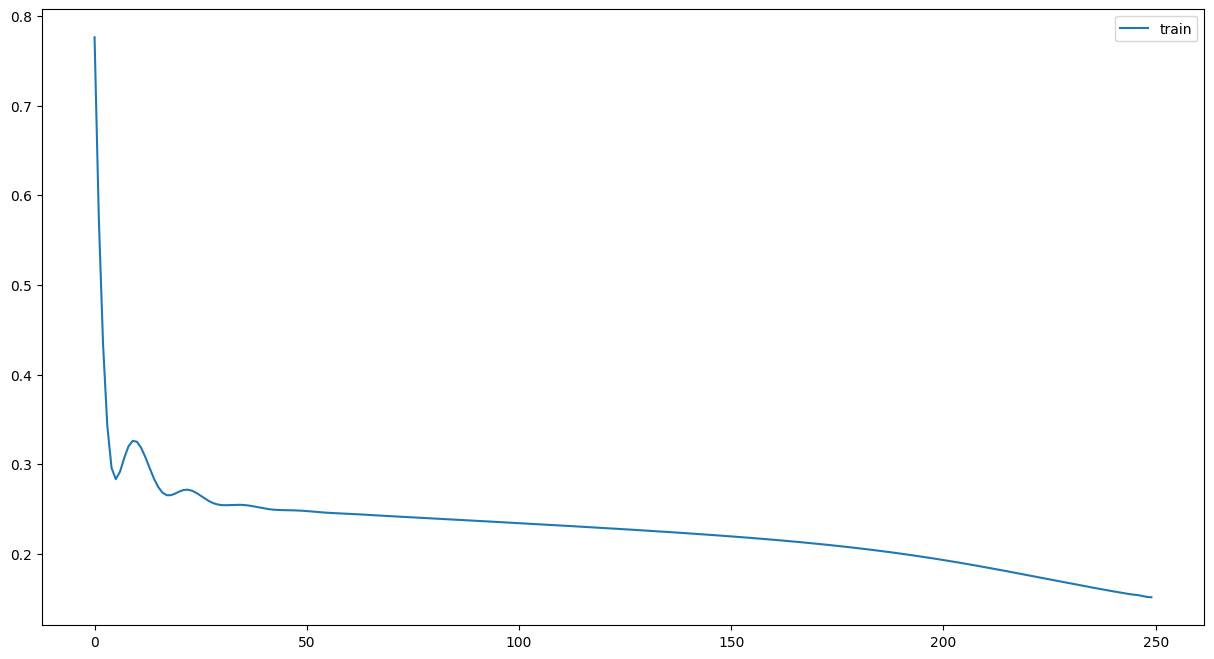

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6079
Accuracy: 0.9115
Precision: 0.5852
Recall: 0.2330
F1: 0.3333


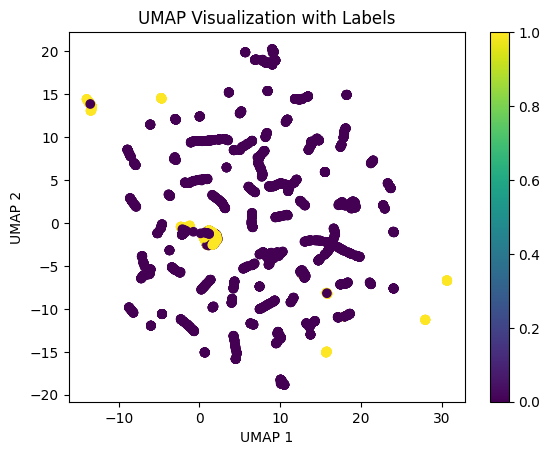

In [ ]:
X = emb_t
y = torch_geo_graphs_unsw1_proto[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

## Traditional (features normalized)

In [ ]:
torch_geo_graphs_unsw1_proto[1]

Data(x=[4843, 4], edge_index=[2, 3532], edge_attr=[3532, 1], y=[3532])

In [ ]:
torch_geo_graphs_unsw1_proto[18]

Data(x=[5354, 4], edge_index=[2, 3572], edge_attr=[3572, 1], y=[3572])

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.6578
Epoch 2/250, Train Loss: 0.4878
Epoch 3/250, Train Loss: 0.3771
Epoch 4/250, Train Loss: 0.3163
Epoch 5/250, Train Loss: 0.2974
Epoch 6/250, Train Loss: 0.3055
Epoch 7/250, Train Loss: 0.3221
Epoch 8/250, Train Loss: 0.3343
Epoch 9/250, Train Loss: 0.3379
Epoch 10/250, Train Loss: 0.3334
Epoch 11/250, Train Loss: 0.3233
Epoch 12/250, Train Loss: 0.3104
Epoch 13/250, Train Loss: 0.2976
Epoch 14/250, Train Loss: 0.2873
Epoch 15/250, Train Loss: 0.2809
Epoch 16/250, Train Loss: 0.2789
Epoch 17/250, Train Loss: 0.2803
Epoch 18/250, Train Loss: 0.2832
Epoch 19/250, Train Loss: 0.2853
Epoch 20/250, Train Loss: 0.2852
Epoch 21/250, Train Loss: 0.2826
Epoch 22/250, Train Loss: 0.2785
Epoch 23/250, Train Loss: 0.2739
Epoch 24/250, Train Loss: 0.2699
Epoch 25/250, Train Loss: 0.2669
Epoch 26/250, Train Loss: 0.2652
Epoch 27/250, Train Loss: 0.2644
Epoch 28/250, Train Loss: 0.2643
Epoch 29/250, Train Loss: 0.2644
Epoch 30/250, Train Loss: 0.2644
Epoch 31/250, Train

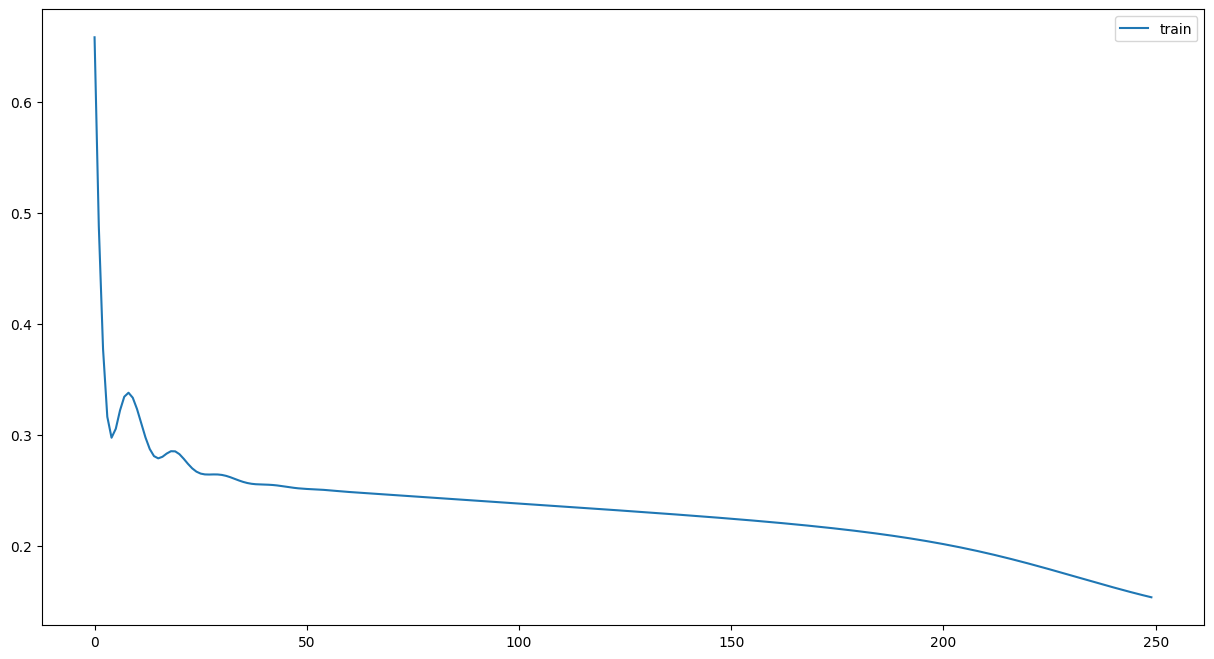

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.6208
Accuracy: 0.9135
Precision: 0.6027
Recall: 0.2596
F1: 0.3629


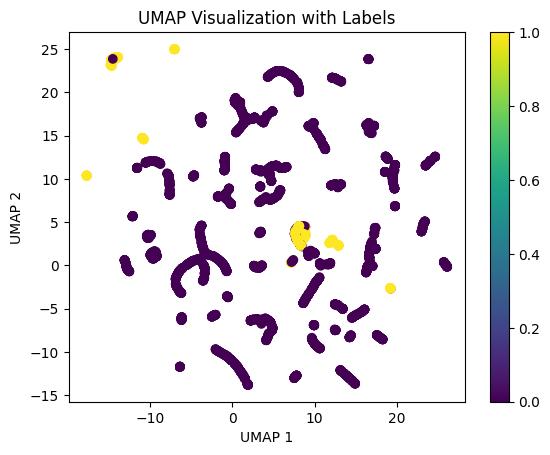

In [ ]:
X = emb_t
y = torch_geo_graphs_unsw1_proto[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

## Traditional (more features normalized)

In [ ]:
torch_geo_graphs_unsw1_proto_more[1]

Data(x=[4843, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532])

In [ ]:
torch_geo_graphs_unsw1_proto_more[18]

Data(x=[5354, 14], edge_index=[2, 3572], edge_attr=[3572, 3], y=[3572])

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

#scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


#ratio_neg_to_pos = 2
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = [18] #list(range(28)) #30
#val_windows = list(range(31,36))#28,36)) #30,39


# Train
epochs = 250
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    # model1.eval()
    # val_loss = 0
    # total_val_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    # with torch.no_grad():
    #     for window in val_windows:
    #         data = torch_geo_graphs_unsw1_proto[window].to(device)
    #         out = model1(data)
    #         loss = criterion(out.squeeze(), data.y.to(device).float())
    #         probabilities = torch.sigmoid(out)
    #         preds = (probabilities.view(-1) > 0.4).long()
    #         # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
    #         num_edges = data.y.size(0)
    #         val_loss += loss.item() * num_edges
    #         total_val_edges += num_edges
    #         all_preds_m1.extend(preds)
    #         all_labels_m1.extend(data.y.cpu().numpy())
    # val_loss_final = val_loss / total_val_edges #len(val_windows)
    # val_losses_m1.append(val_loss_final)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # # Actualizar el scheduler
    # scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")#, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/250, Train Loss: 0.7936
Epoch 2/250, Train Loss: 0.6695
Epoch 3/250, Train Loss: 0.5633
Epoch 4/250, Train Loss: 0.4700
Epoch 5/250, Train Loss: 0.3917
Epoch 6/250, Train Loss: 0.3322
Epoch 7/250, Train Loss: 0.2938
Epoch 8/250, Train Loss: 0.2741
Epoch 9/250, Train Loss: 0.2657
Epoch 10/250, Train Loss: 0.2606
Epoch 11/250, Train Loss: 0.2523
Epoch 12/250, Train Loss: 0.2383
Epoch 13/250, Train Loss: 0.2186
Epoch 14/250, Train Loss: 0.1952
Epoch 15/250, Train Loss: 0.1709
Epoch 16/250, Train Loss: 0.1487
Epoch 17/250, Train Loss: 0.1312
Epoch 18/250, Train Loss: 0.1194
Epoch 19/250, Train Loss: 0.1130
Epoch 20/250, Train Loss: 0.1106
Epoch 21/250, Train Loss: 0.1105
Epoch 22/250, Train Loss: 0.1109
Epoch 23/250, Train Loss: 0.1106
Epoch 24/250, Train Loss: 0.1092
Epoch 25/250, Train Loss: 0.1064
Epoch 26/250, Train Loss: 0.1027
Epoch 27/250, Train Loss: 0.0982
Epoch 28/250, Train Loss: 0.0933
Epoch 29/250, Train Loss: 0.0885
Epoch 30/250, Train Loss: 0.0839
Epoch 31/250, Train

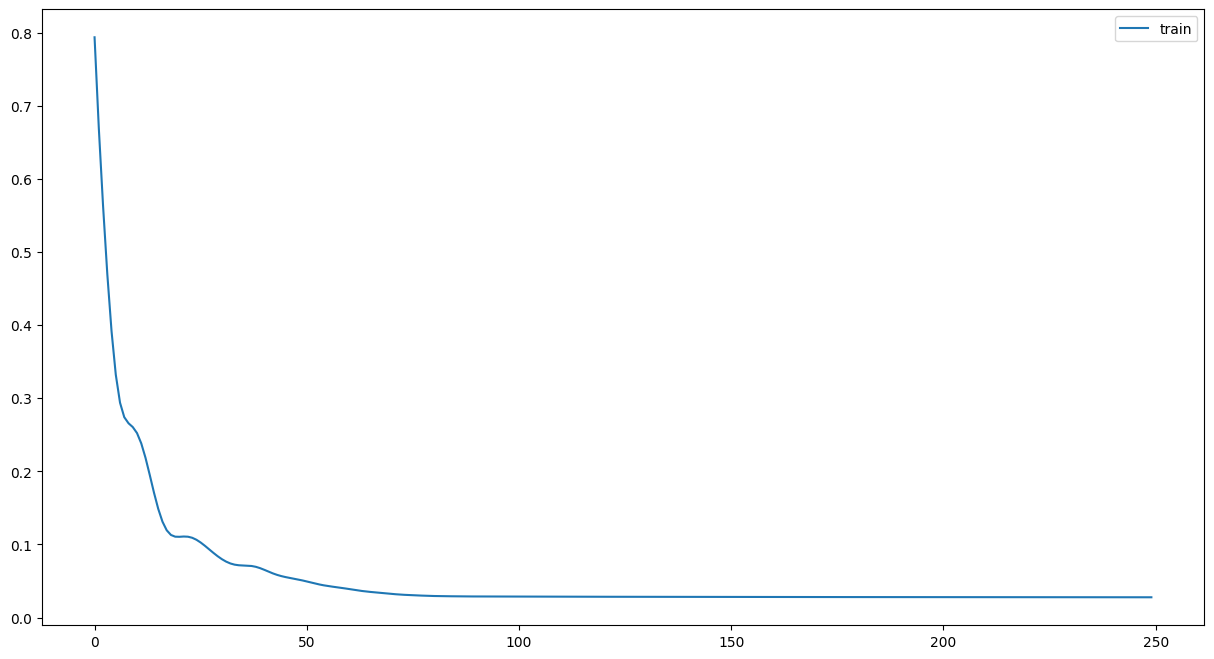

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(250), train_losses_m1, label="train")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.9607
Accuracy: 0.9910
Precision: 0.9812
Recall: 0.9233
F1: 0.9514


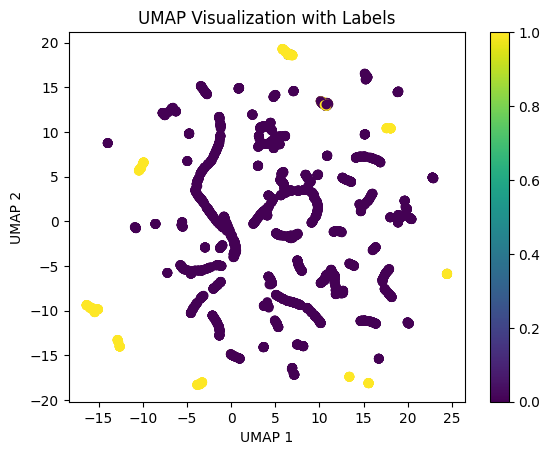

In [ ]:
X = emb_t
y = torch_geo_graphs_unsw1_proto_more[18].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

In [ ]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
with torch.no_grad():
    for window in [1]:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.9666
Accuracy: 0.9892
Precision: 0.9331
Recall: 0.9394
F1: 0.9362


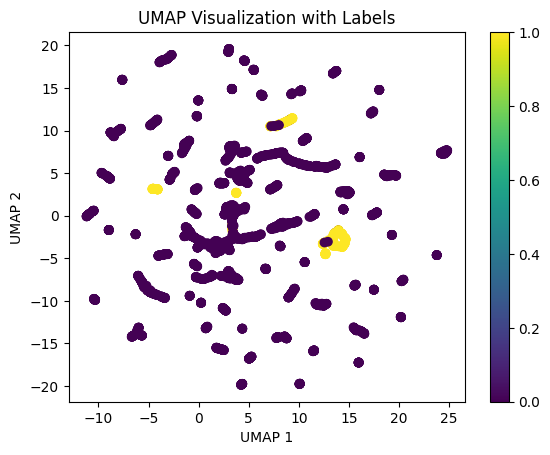

In [ ]:
X = emb_v
y = torch_geo_graphs_unsw1_proto_more[1].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()

# Train and test with all snapshots

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Model 1_1: Traditional (features normalized)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_1 = GNN_traditional_normalize(node_input_dim=4, edge_input_dim=1, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 75
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto[window].to(device)
            out,_ = model1_1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/75, Train Loss: 0.2642, Val Loss: 0.1822, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/75, Train Loss: 0.1997, Val Loss: 0.1647, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/75, Train Loss: 0.1913, Val Loss: 0.1577, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 4/75, Train Loss: 0.1862, Val Loss: 0.1532, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 5/75, Train Loss: 0.1823, Val Loss: 0.1499, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 6/75, Train Loss: 0.1788, Val Loss: 0.1473, , Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 7/75, Train Loss: 0.1754, Val Loss: 0.1449, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 8/75, Train Loss: 0.1719, Val Loss: 0.1446, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 9/75, Train Loss: 0.1705, Val Loss: 0.1436, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 10/75, Train Loss: 0.1690, Val Loss: 0.1425, , Current LR: 0.005000, ROC-AUC: 0.5, F1:0.0
Epoch 11/75, Train Loss: 0.1675, Val Loss: 0.1414

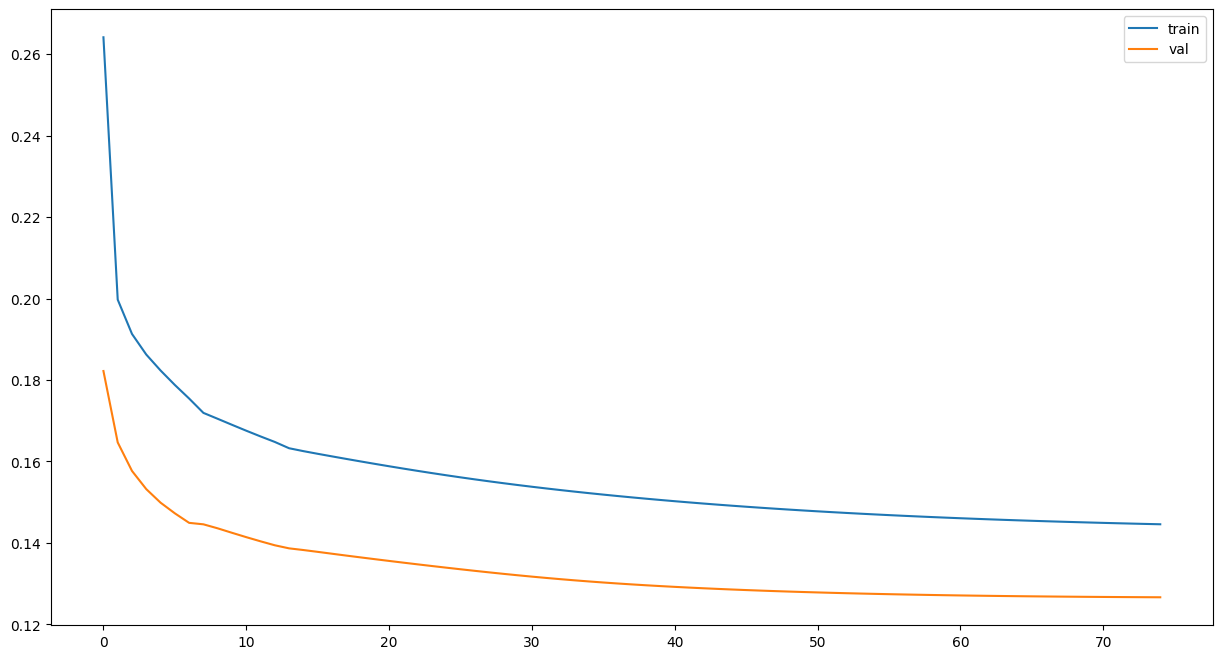

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(75), train_losses_m1, label="train")
axs.plot(range(75), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación training set
model1_1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_training = []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_training.append(emb_t)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_1:.4f}")
print(f"Accuracy: {accuracy_m1_1:.4f}")
print(f"Precision: {precision_m1_1:.4f}")
print(f"Recall: {recall_m1_1:.4f}")
print(f"F1: {f1_m1_1:.4f}")



ROC-AUC: 0.5479
Accuracy: 0.9452
Precision: 0.5128
Recall: 0.1015
F1: 0.1694


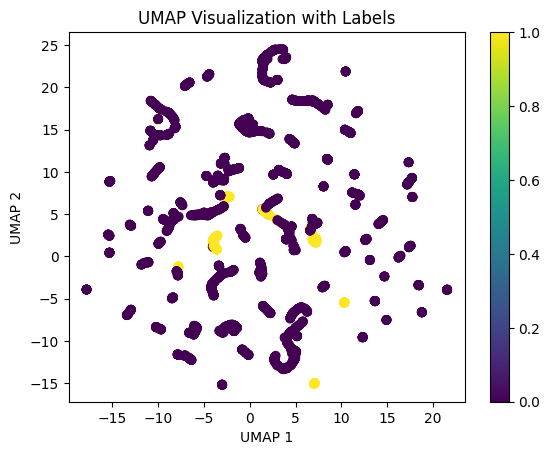

In [ ]:
# Vemos un embedding a modo de ejemplo

X = embeddings_training[1]
y = torch_geo_graphs_unsw1_proto[1].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()


In [ ]:
# Evaluación validation set
model1_1.eval()
all_preds_m1_1, all_labels_m1_1 = [], []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto[window].to(device)
        out,emb_v = model1_1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1_1.extend(preds)
        all_labels_m1_1.extend(data.y.cpu().numpy())

# Metrics
roc_auc_m1_1 = roc_auc_score(all_labels_m1_1, all_preds_m1_1)
accuracy_m1_1 = accuracy_score(all_labels_m1_1, all_preds_m1_1)
precision_m1_1 = precision_score(all_labels_m1_1, all_preds_m1_1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_1 = recall_score(all_labels_m1_1, all_preds_m1_1, average='binary', zero_division=0)
f1_m1_1 = f1_score(all_labels_m1_1, all_preds_m1_1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_1:.4f}")
print(f"Accuracy: {accuracy_m1_1:.4f}")
print(f"Precision: {precision_m1_1:.4f}")
print(f"Recall: {recall_m1_1:.4f}")
print(f"F1: {f1_m1_1:.4f}")



ROC-AUC: 0.5501
Accuracy: 0.9539
Precision: 0.4118
Recall: 0.1073
F1: 0.1702


## Model 1_2: Traditional (more features normalized)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more[window].to(device)
            out,_ = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2115, Val Loss: 0.0978, , Current LR: 0.010000, ROC-AUC: 0.9417358535005594, F1:0.6505159264244056
Epoch 2/15, Train Loss: 0.0901, Val Loss: 0.0805, , Current LR: 0.010000, ROC-AUC: 0.9360770506815131, F1:0.6459179070816419
Epoch 3/15, Train Loss: 0.0774, Val Loss: 0.0709, , Current LR: 0.010000, ROC-AUC: 0.9202518948969253, F1:0.7091383812010443
Epoch 4/15, Train Loss: 0.0677, Val Loss: 0.0647, , Current LR: 0.010000, ROC-AUC: 0.8474803403809489, F1:0.671875
Epoch 5/15, Train Loss: 0.0597, Val Loss: 0.0619, , Current LR: 0.010000, ROC-AUC: 0.8132991003173559, F1:0.6640159045725647
Epoch 6/15, Train Loss: 0.0567, Val Loss: 0.0617, , Current LR: 0.010000, ROC-AUC: 0.7942008946065741, F1:0.6377792823290453
Epoch 7/15, Train Loss: 0.0557, Val Loss: 0.0614, , Current LR: 0.010000, ROC-AUC: 0.7979236843334206, F1:0.6502732240437158
Epoch 8/15, Train Loss: 0.0552, Val Loss: 0.0610, , Current LR: 0.010000, ROC-AUC: 0.8040738507269948, F1:0.6558704453441295
Epoch 9/15

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more[window].to(device)
            out,_ = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2234, Val Loss: 0.1037, , Current LR: 0.010000, ROC-AUC: 0.9543011571409138, F1:0.6604609929078015
Epoch 2/15, Train Loss: 0.0924, Val Loss: 0.0828, , Current LR: 0.010000, ROC-AUC: 0.9335522134710776, F1:0.64376130198915
Epoch 3/15, Train Loss: 0.0781, Val Loss: 0.0731, , Current LR: 0.010000, ROC-AUC: 0.9379277857979683, F1:0.7036669970267592
Epoch 4/15, Train Loss: 0.0687, Val Loss: 0.0663, , Current LR: 0.010000, ROC-AUC: 0.8506731884013831, F1:0.6758538046734571
Epoch 5/15, Train Loss: 0.0605, Val Loss: 0.0622, , Current LR: 0.010000, ROC-AUC: 0.8121711975667352, F1:0.6394904458598726
Epoch 6/15, Train Loss: 0.0568, Val Loss: 0.0617, , Current LR: 0.010000, ROC-AUC: 0.7916466161902267, F1:0.6340801086218602
Epoch 7/15, Train Loss: 0.0556, Val Loss: 0.0615, , Current LR: 0.010000, ROC-AUC: 0.7848081347067147, F1:0.6350314026517795
Epoch 8/15, Train Loss: 0.0550, Val Loss: 0.0612, , Current LR: 0.010000, ROC-AUC: 0.7882365123744435, F1:0.6433566433566433
Ep

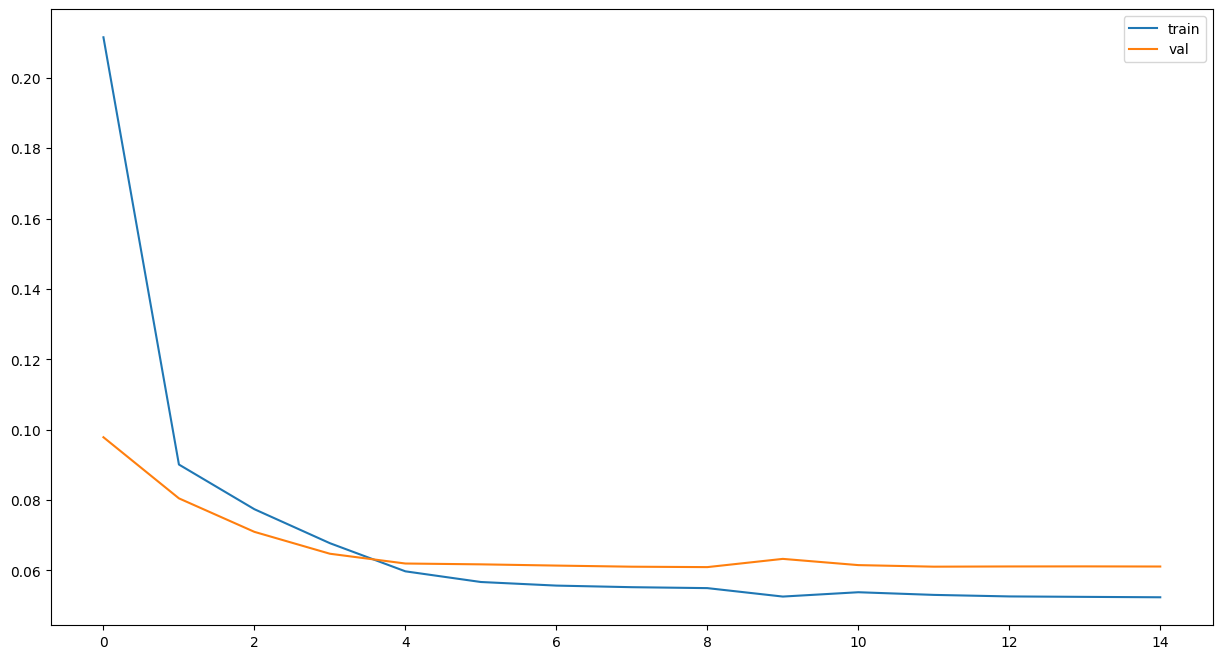

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_training = []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_training.append(emb_t)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")

# ROC-AUC: 0.8967
# Accuracy: 0.9792
# Precision: 0.8152
# Recall: 0.8040
# F1: 0.8095

ROC-AUC: 0.8896
Accuracy: 0.9773
Precision: 0.7953
Recall: 0.7911
F1: 0.7932


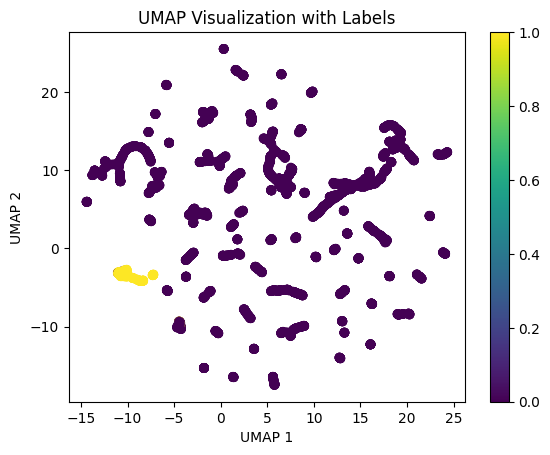

In [ ]:
# Vemos un embedding a modo de ejemplo


X = embeddings_training[2]
y = torch_geo_graphs_unsw1_proto_more[2].y

umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(X)

plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization with Labels')
plt.show()


<ipython-input-27-c803a339a522>:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


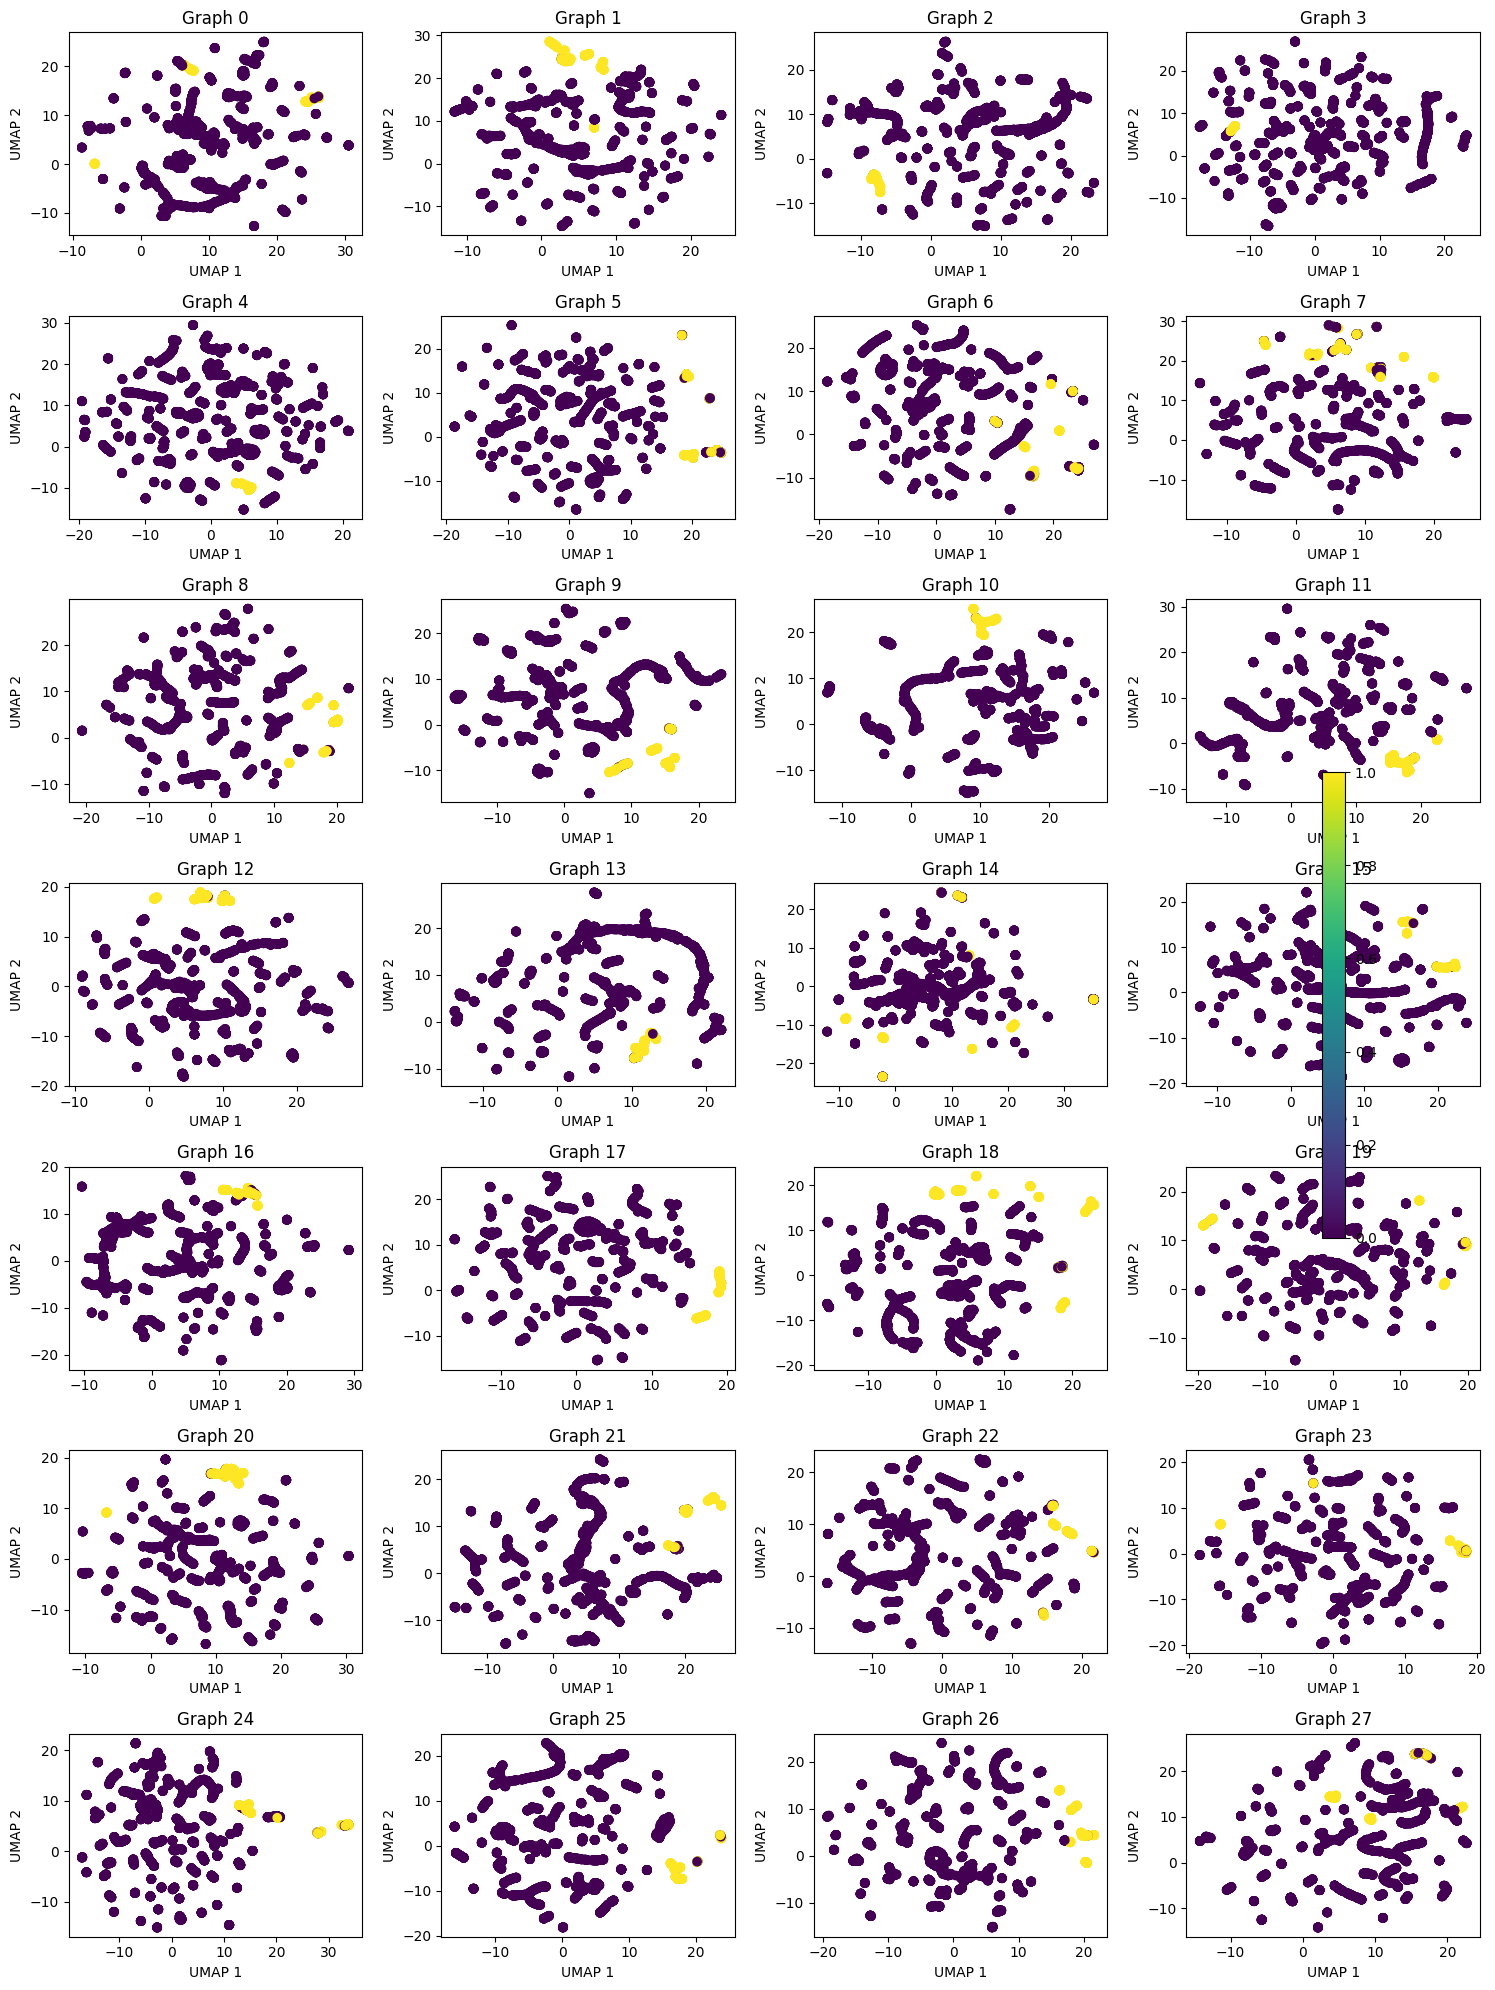

In [ ]:
import matplotlib.pyplot as plt

num_graphs = 28
rows, cols = 7, 4  # Adjust the grid dimensions as needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 20))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_training[i]  # Feature embeddings
    y = torch_geo_graphs_unsw1_proto_more[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()


In [ ]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_validation = []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto_more[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.8065
Accuracy: 0.9724
Precision: 0.7139
Recall: 0.6245
F1: 0.6662


In [ ]:
val_windows

[31, 32, 33, 34, 35]

<ipython-input-36-47fea39ae811>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


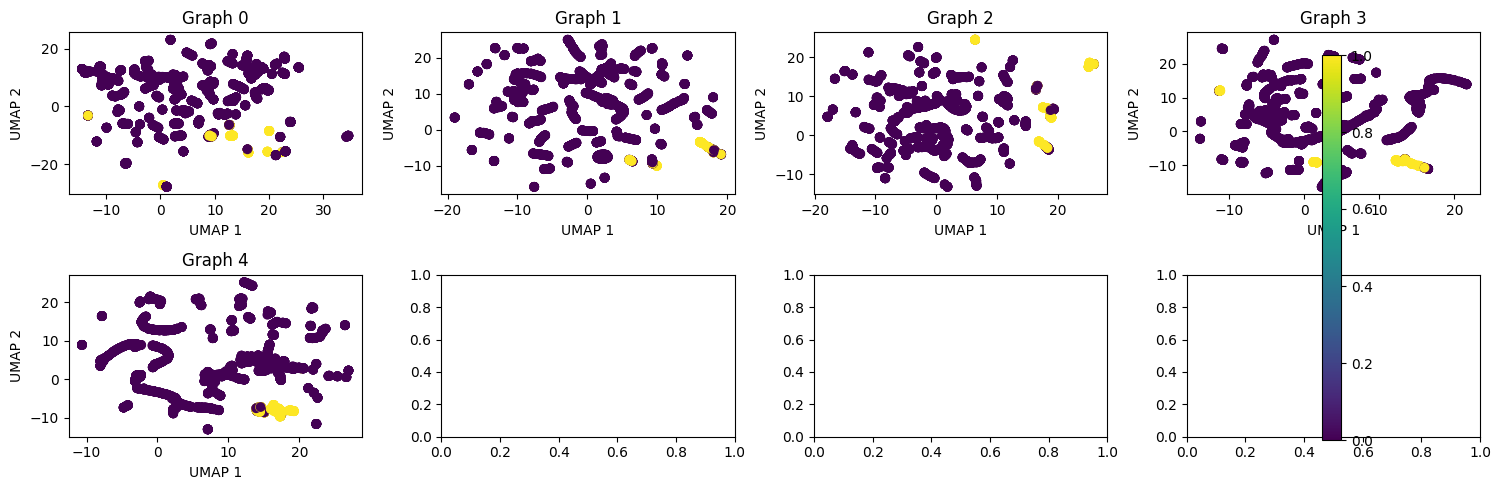

In [ ]:
num_graphs = 5
rows, cols = 2, 4  # Adjust the grid dimensions as needed

fig, axes = plt.subplots(rows, cols, figsize=(15,5))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_validation[i]  # Feature embeddings
    y = torch_geo_graphs_unsw1_proto_more[i+31].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

## Model 1_3: Traditional (more features normalized 2: included nominal edge features)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=19, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more2[window].to(device)
        optimizer.zero_grad()
        out,_ = model1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more2[window].to(device)
            out,_ = model1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2480, Val Loss: 0.1149, , Current LR: 0.010000, ROC-AUC: 0.9531529501103537, F1:0.6492374727668845
Epoch 2/15, Train Loss: 0.0901, Val Loss: 0.0842, , Current LR: 0.010000, ROC-AUC: 0.9478565786882217, F1:0.6539145907473309
Epoch 3/15, Train Loss: 0.0693, Val Loss: 0.0784, , Current LR: 0.010000, ROC-AUC: 0.932884202661079, F1:0.6428571428571429
Epoch 4/15, Train Loss: 0.0585, Val Loss: 0.0767, , Current LR: 0.010000, ROC-AUC: 0.9306740817897006, F1:0.6381252816584047
Epoch 5/15, Train Loss: 0.0508, Val Loss: 0.0716, , Current LR: 0.010000, ROC-AUC: 0.9260386146795884, F1:0.62129916040654
Epoch 6/15, Train Loss: 0.0466, Val Loss: 0.0669, , Current LR: 0.010000, ROC-AUC: 0.9066764533295973, F1:0.6786632390745502
Epoch 7/15, Train Loss: 0.0449, Val Loss: 0.0650, , Current LR: 0.010000, ROC-AUC: 0.8887558958552874, F1:0.6727175654030967
Epoch 8/15, Train Loss: 0.0439, Val Loss: 0.0645, , Current LR: 0.010000, ROC-AUC: 0.8879792571476142, F1:0.6774541531823085
Epo

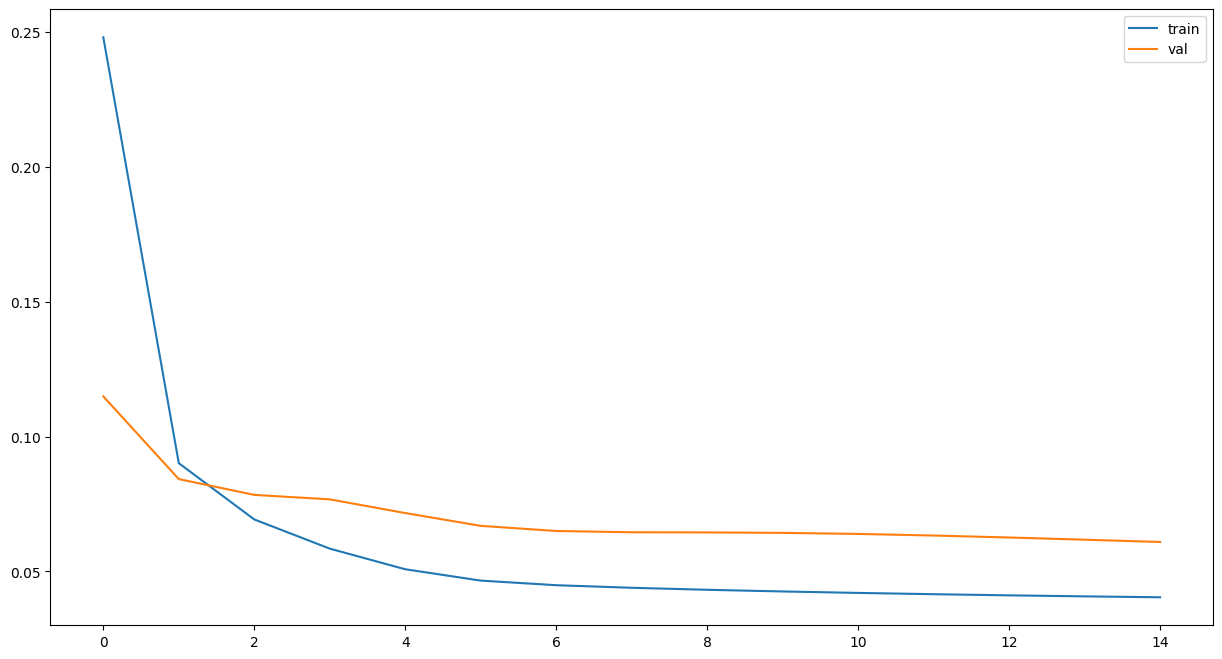

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación training set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_training = []
with torch.no_grad():
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more2[window].to(device)
        out,emb_t = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_training.append(emb_t)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")


ROC-AUC: 0.9309
Accuracy: 0.9838
Precision: 0.8398
Recall: 0.8715
F1: 0.8553


<ipython-input-56-a82d427a5689>:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


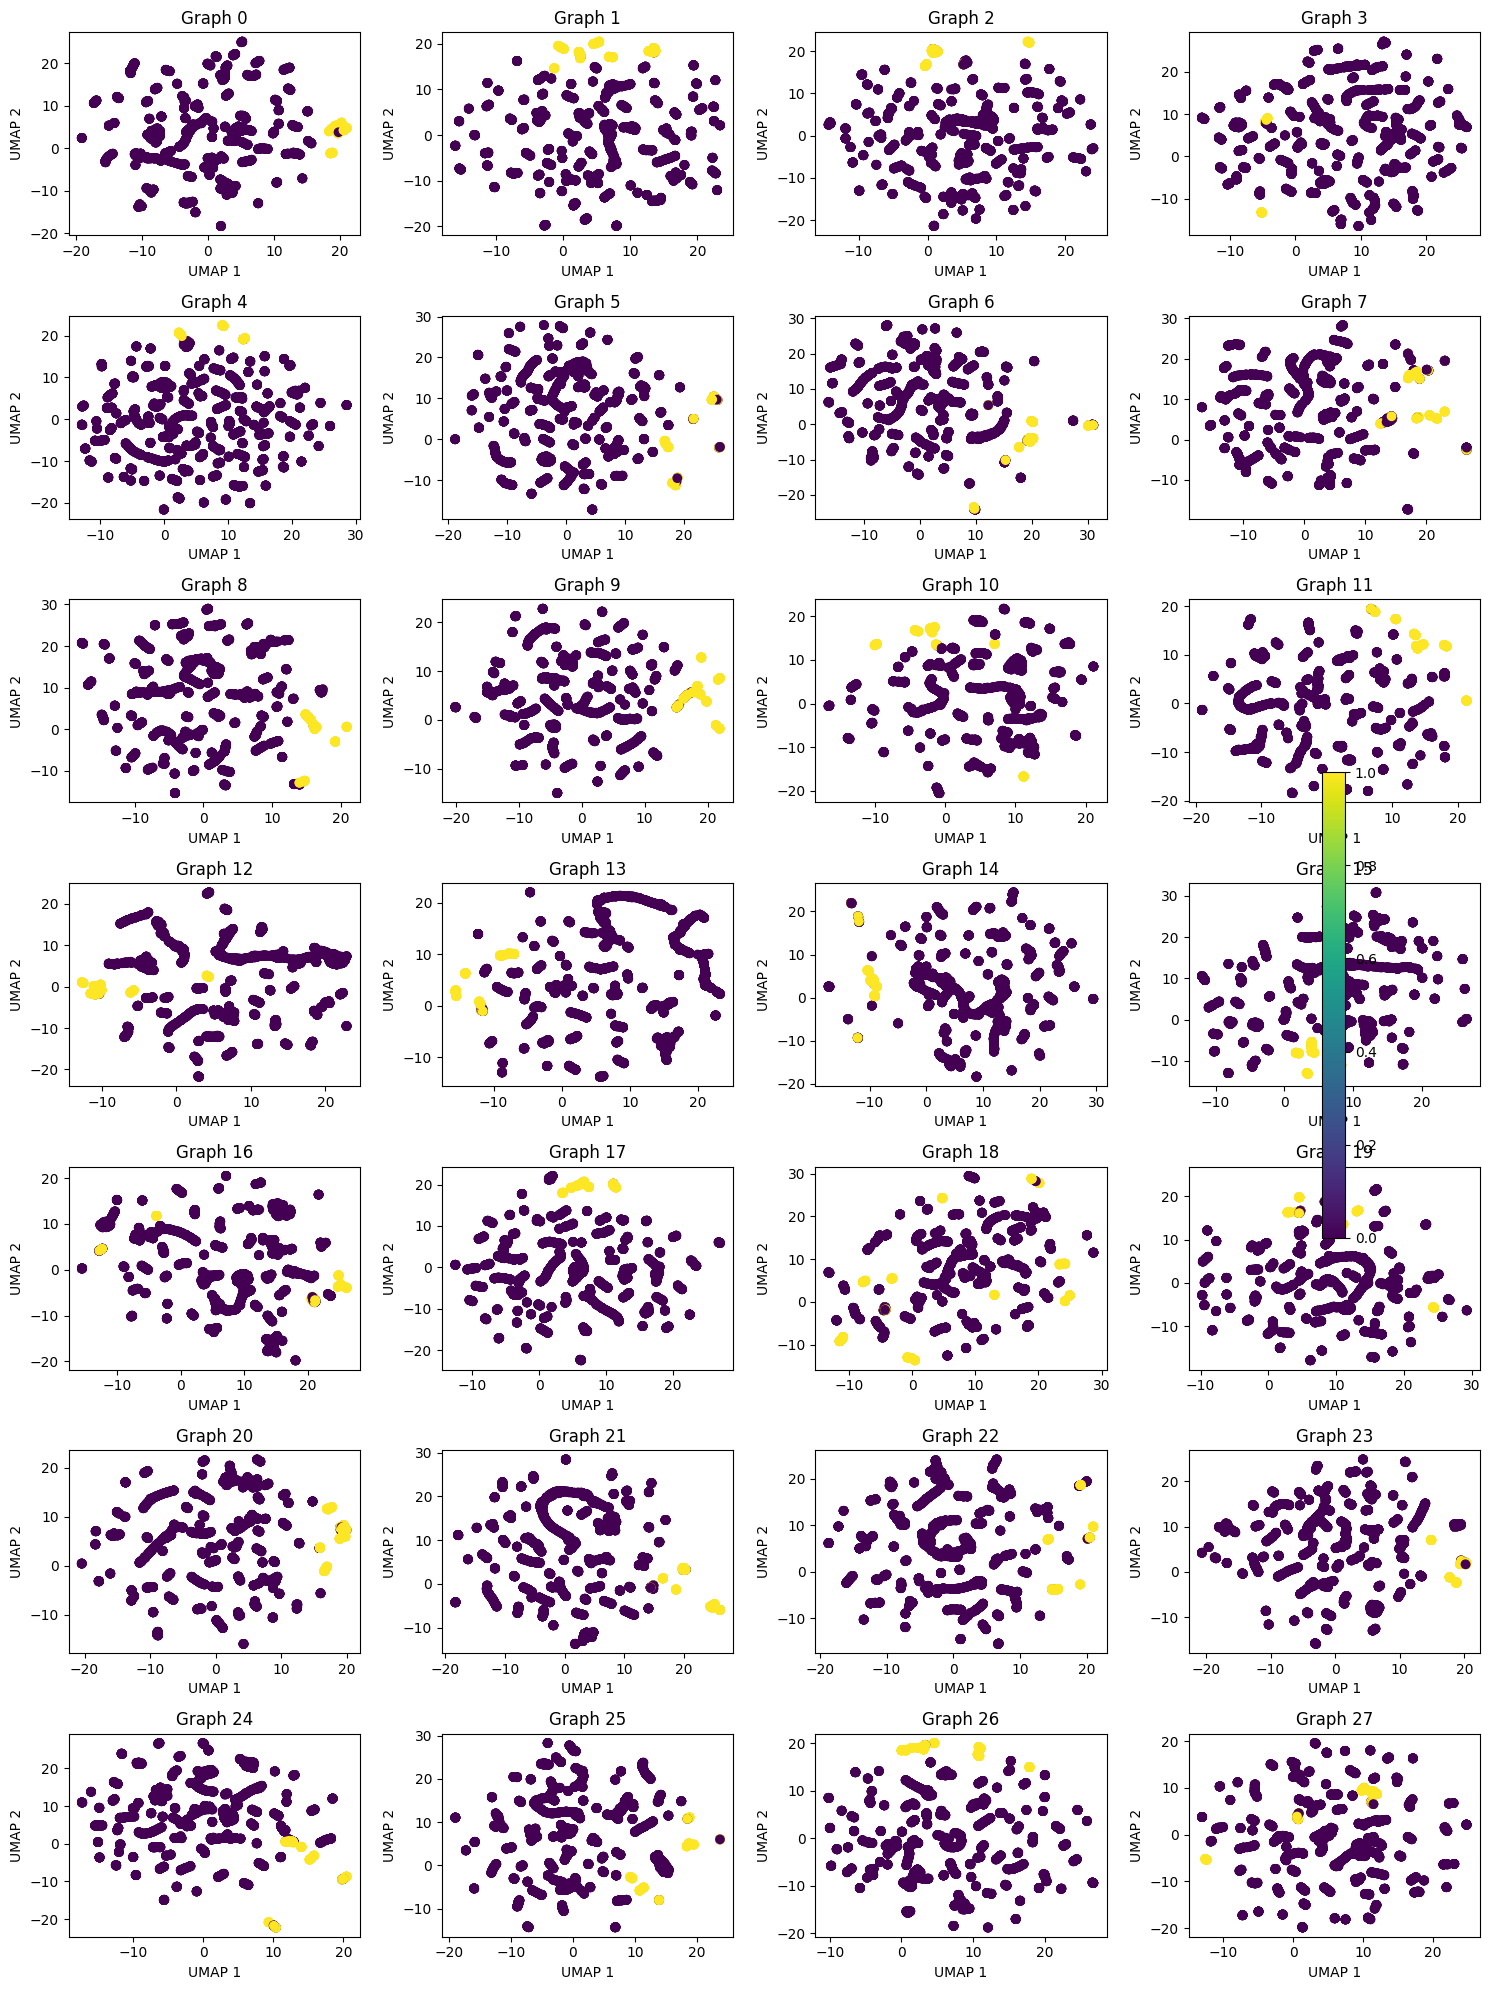

In [ ]:
num_graphs = 28
rows, cols = 7, 4  # Adjust the grid dimensions as needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 20))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_training[i]  # Feature embeddings
    y = torch_geo_graphs_unsw1_proto_more2[i].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
# Evaluación validation set
model1.eval()
all_preds_m1, all_labels_m1 = [], []
embeddings_validation = []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto_more2[window].to(device)
        out,emb_v = model1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1.extend(preds)
        all_labels_m1.extend(data.y.cpu().numpy())
        embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
accuracy_m1 = accuracy_score(all_labels_m1, all_preds_m1)
precision_m1 = precision_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1 = recall_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)
f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1:.4f}")
print(f"Accuracy: {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall: {recall_m1:.4f}")
print(f"F1: {f1_m1:.4f}")



ROC-AUC: 0.8962
Accuracy: 0.9681
Precision: 0.6021
Recall: 0.8174
F1: 0.6934


<ipython-input-70-2fcdb964816e>:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


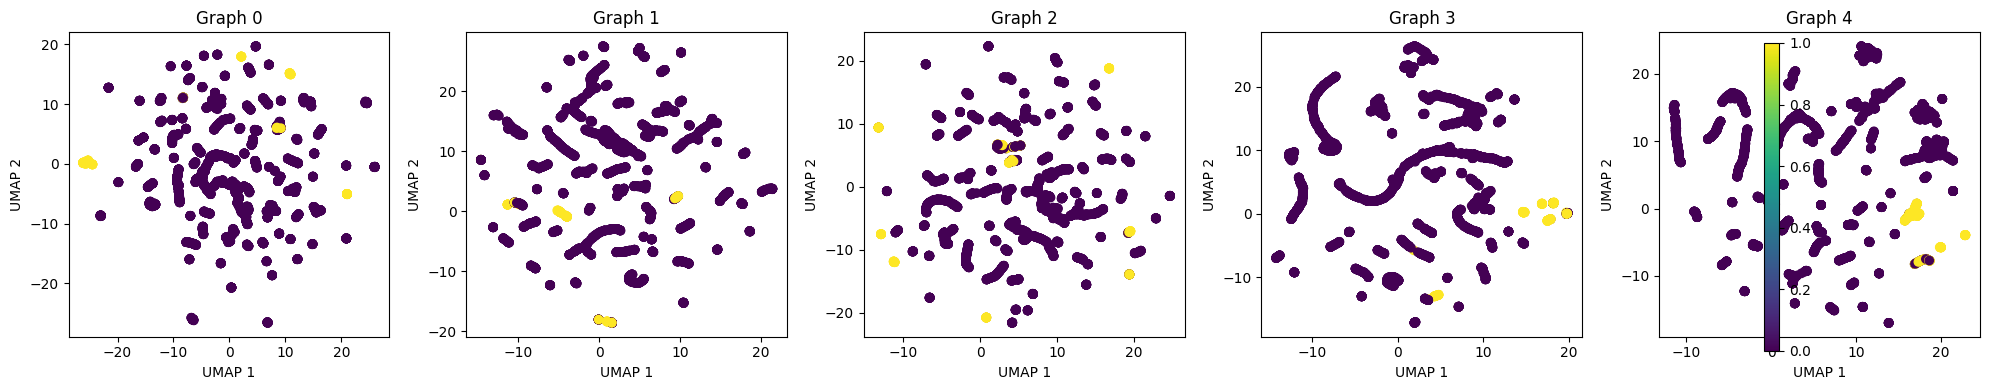

In [ ]:
import matplotlib.pyplot as plt
import umap

# Assuming embeddings_training and torch_geo_graphs_unsw1_proto are defined
num_graphs = 5
rows, cols = 1,5  # Adjust the grid dimensions as needed
fig, axes = plt.subplots(rows, cols, figsize=(20, 4))
axes = axes.flatten()

for i in range(num_graphs):
    X = embeddings_validation[i]  # Feature embeddings
    y = torch_geo_graphs_unsw1_proto_more2[i+31].y  # Labels

    # Apply UMAP dimensionality reduction
    umap_model = umap.UMAP(n_components=2)
    umap_result = umap_model.fit_transform(X)

    # Scatter plot for the current graph
    ax = axes[i]
    #scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='tab10', s=10)
    scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], c=y, cmap='viridis')
    ax.set_title(f'Graph {i}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

# Add a single colorbar for all subplots
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

# Adjust layout and display
plt.tight_layout()
plt.show()


## Model 1_4: Traditional (more features normalized - 172471 nodes)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2575, Val Loss: 0.1084, , Current LR: 0.010000, ROC-AUC: 0.9615355720832395, F1:0.6360601001669449
Epoch 2/15, Train Loss: 0.0922, Val Loss: 0.0799, , Current LR: 0.010000, ROC-AUC: 0.9386018878919488, F1:0.648064806480648
Epoch 3/15, Train Loss: 0.0773, Val Loss: 0.0720, , Current LR: 0.010000, ROC-AUC: 0.8625704812317389, F1:0.6875
Epoch 4/15, Train Loss: 0.0685, Val Loss: 0.0663, , Current LR: 0.010000, ROC-AUC: 0.8390408664242335, F1:0.6674831598285365
Epoch 5/15, Train Loss: 0.0611, Val Loss: 0.0628, , Current LR: 0.010000, ROC-AUC: 0.8051763731276916, F1:0.6302952503209243
Epoch 6/15, Train Loss: 0.0574, Val Loss: 0.0619, , Current LR: 0.010000, ROC-AUC: 0.7948394642106609, F1:0.638700947225981
Epoch 7/15, Train Loss: 0.0559, Val Loss: 0.0617, , Current LR: 0.010000, ROC-AUC: 0.7873238349911779, F1:0.6297056810403833
Epoch 8/15, Train Loss: 0.0552, Val Loss: 0.0614, , Current LR: 0.010000, ROC-AUC: 0.7848081347067147, F1:0.6350314026517795
Epoch 9/15, Tr

In [ ]:
# Evaluación validation set
model1_4.eval()
all_preds_m1_4, all_labels_m1_4 = [], []
all_preds_m1_4_list, all_labels_m1_4_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        out,emb_v = model1_4(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1_4.extend(preds)
        all_labels_m1_4.extend(data.y.cpu().numpy())
        all_preds_m1_4_list.append(preds)
        all_labels_m1_4_list.append(data.y.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4 = roc_auc_score(all_labels_m1_4, all_preds_m1_4)
accuracy_m1_4 = accuracy_score(all_labels_m1_4, all_preds_m1_4)
precision_m1_4 = precision_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4 = recall_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)
f1_m1_4 = f1_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4:.4f}")
print(f"Accuracy: {accuracy_m1_4:.4f}")
print(f"Precision: {precision_m1_4:.4f}")
print(f"Recall: {recall_m1_4:.4f}")
print(f"F1: {f1_m1_4:.4f}")



ROC-AUC: 0.8129
Accuracy: 0.9730
Precision: 0.7180
Recall: 0.6373
F1: 0.6752


In [ ]:
for i in range(len(all_labels_m1_4_list)):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m1_4_list[i], all_preds_m1_4_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m1_4_list[i], all_preds_m1_4_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m1_4_list[i], all_preds_m1_4_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m1_4_list[i], all_preds_m1_4_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m1_4_list[i], all_preds_m1_4_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.6526420404147918
Accuracy: 0.9714652956298201
Precision: 0.6721311475409836
Recall: 0.3106060606060606
F1: 0.42487046632124353 

========= i=1 ===========
ROC-AUC: 0.7035793588925897
Accuracy: 0.9814214096136833
Precision: 0.9545454545454546
Recall: 0.4077669902912621
F1: 0.5714285714285714 

========= i=2 ===========
ROC-AUC: 0.833861195023118
Accuracy: 0.9601833285591521
Precision: 0.5825242718446602
Recall: 0.6936416184971098
F1: 0.633245382585752 

========= i=3 ===========
ROC-AUC: 0.8526530532858183
Accuracy: 0.97520184544406
Precision: 0.6802721088435374
Recall: 0.7194244604316546
F1: 0.6993006993006993 

========= i=4 ===========
ROC-AUC: 0.909023234248622
Accuracy: 0.9770277935337492
Precision: 0.8270042194092827
Recall: 0.8305084745762712
F1: 0.828752642706131 



In [ ]:
torch_geo_graphs_unsw2_proto_more_rnn

{0: Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
 1: Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
 2: Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
 3: Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
 4: Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
 5: Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])}

In [ ]:
# Evaluación test
model1_4.eval()
all_preds_m1_4_test, all_labels_m1_4_test = [], []
#embeddings_validation = []
with torch.no_grad():
    #for window in range(len(torch_geo_graphs_unsw2_proto_more_rnn)):
    data = torch_geo_graphs_unsw2_proto_more_rnn[5].to(device) # SOLO DEBE PREDECIR EN EL ULTIMO
    out,emb_v = model1_4(data)
    probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
    # Convert probabilities to binary predictions using a threshold
    preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

    all_preds_m1_4_test.extend(preds)
    all_labels_m1_4_test.extend(data.y.cpu().numpy())
    #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4_test = roc_auc_score(all_labels_m1_4_test, all_preds_m1_4_test)
accuracy_m1_4_test = accuracy_score(all_labels_m1_4_test, all_preds_m1_4_test)
precision_m1_4_test = precision_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_test = recall_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)
f1_m1_4_test = f1_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_test:.4f}")
print(f"Precision: {precision_m1_4_test:.4f}")
print(f"Recall: {recall_m1_4_test:.4f}")
print(f"F1: {f1_m1_4_test:.4f}")

ROC-AUC: 0.8761
Accuracy: 0.9683
Precision: 0.6534
Recall: 0.7737
F1: 0.7085


In [ ]:
len(all_labels_m1_4_test)

38685

## GNN + RNN (more features normalized - 172471 nodes)

### Model 2_1: seq_len=4 - 25 windows for train, 5 for val

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_1 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_1.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out = model2_1(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2487, Val Loss: 0.1055, Current LR: 0.010000, ROC-AUC: 0.9042896852227482, F1:0.6710929519918284
Epoch 2/15, Train Loss: 0.0786, Val Loss: 0.0883, Current LR: 0.010000, ROC-AUC: 0.9552605343680395, F1:0.61140315406389
Epoch 3/15, Train Loss: 0.0685, Val Loss: 0.0766, Current LR: 0.010000, ROC-AUC: 0.9470576052726153, F1:0.6816269284712483
Epoch 4/15, Train Loss: 0.0580, Val Loss: 0.0745, Current LR: 0.010000, ROC-AUC: 0.9468809580371446, F1:0.6797202797202797
Epoch 5/15, Train Loss: 0.0568, Val Loss: 0.0766, Current LR: 0.010000, ROC-AUC: 0.9762165816932551, F1:0.7006772009029345
Epoch 6/15, Train Loss: 0.0588, Val Loss: 0.0727, Current LR: 0.010000, ROC-AUC: 0.9573833468356795, F1:0.6862925482980681
Epoch 7/15, Train Loss: 0.0545, Val Loss: 0.0723, Current LR: 0.010000, ROC-AUC: 0.9592493101620891, F1:0.6938775510204082
Epoch 8/15, Train Loss: 0.0544, Val Loss: 0.0725, Current LR: 0.010000, ROC-AUC: 0.9765993173701085, F1:0.7048138056312443
Epoch 9/15, Train 

In [ ]:
# Evaluación validation set
model2_1.eval()
all_preds_m2_1, all_labels_m2_1 = [], []
all_preds_m2_1_list, all_labels_m2_1_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val)):
        data_list = windows_input_val[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val[window][-1].y
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_1.extend(preds)
        all_labels_m2_1.extend(labels.cpu().numpy())
        all_preds_m2_1_list.append(preds)
        all_labels_m2_1_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_1 = roc_auc_score(all_labels_m2_1, all_preds_m2_1)
accuracy_m2_1 = accuracy_score(all_labels_m2_1, all_preds_m2_1)
precision_m2_1 = precision_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_1 = recall_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)
f1_m2_1 = f1_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_1:.4f}")
print(f"Accuracy: {accuracy_m2_1:.4f}")
print(f"Precision: {precision_m2_1:.4f}")
print(f"Recall: {recall_m2_1:.4f}")
print(f"F1: {f1_m2_1:.4f}")

# ROC-AUC: 0.9642
# Accuracy: 0.9676
# Precision: 0.5802
# Recall: 0.9604
# F1: 0.7234

ROC-AUC: 0.9676
Accuracy: 0.9626
Precision: 0.5420
Recall: 0.9732
F1: 0.6962


In [ ]:
# 172K nodes
ROC-AUC: 0.8154
Accuracy: 0.9732
Precision: 0.7186
Recall: 0.6424
F1: 0.6784

# different nodes
ROC-AUC: 0.8065
Accuracy: 0.9724
Precision: 0.7139
Recall: 0.6245
F1: 0.6662

In [ ]:
for i in range(5):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_1_list[i], all_preds_m2_1_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_1_list[i], all_preds_m2_1_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_1_list[i], all_preds_m2_1_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_1_list[i], all_preds_m2_1_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_1_list[i], all_preds_m2_1_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.9040108374860903
Accuracy: 0.9416452442159383
Precision: 0.35294117647058826
Recall: 0.8636363636363636
F1: 0.5010989010989011 

========= i=1 ===========
ROC-AUC: 0.97323600973236
Accuracy: 0.9480979062223532
Precision: 0.36917562724014336
Recall: 1.0
F1: 0.5392670157068062 

========= i=2 ===========
ROC-AUC: 0.9760397830018084
Accuracy: 0.9544543110856488
Precision: 0.5210843373493976
Recall: 1.0
F1: 0.6851485148514852 

========= i=3 ===========
ROC-AUC: 0.987541357721873
Accuracy: 0.9826989619377162
Precision: 0.700507614213198
Recall: 0.9928057553956835
F1: 0.8214285714285714 

========= i=4 ===========
ROC-AUC: 0.989531708824893
Accuracy: 0.9878048780487805
Precision: 0.850909090909091
Recall: 0.9915254237288136
F1: 0.9158512720156555 



In [ ]:
# Evaluación test
model2_1.eval()
all_preds_m2_1_test, all_labels_m2_1_test = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_1_test.extend(preds)
        all_labels_m2_1_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_1_test = roc_auc_score(all_labels_m2_1_test, all_preds_m2_1_test)
accuracy_m2_1_test = accuracy_score(all_labels_m2_1_test, all_preds_m2_1_test)
precision_m2_1_test = precision_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_1_test = recall_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)
f1_m2_1_test = f1_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_1_test:.4f}")
print(f"Precision: {precision_m2_1_test:.4f}")
print(f"Recall: {recall_m2_1_test:.4f}")
print(f"F1: {f1_m2_1_test:.4f}")

ROC-AUC: 0.9664
Accuracy: 0.9642
Precision: 0.5849
Recall: 0.9689
F1: 0.7294


#### Model 2_2: Reusing h

In [ ]:
max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

3890

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_2 = EdgeClassificationModel_RNN_v2(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_2.to(device)
optimizer = torch.optim.Adam(model2_2.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_train[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_2.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out, _ = model2_2(data, max_num_edges_train)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out, h_n = model2_2(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2695, Val Loss: 0.1688, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.0860, Val Loss: 0.0864, Current LR: 0.010000, ROC-AUC: 0.8638811225018123, F1:0.6448445171849427
Epoch 3/15, Train Loss: 0.0629, Val Loss: 0.0925, Current LR: 0.010000, ROC-AUC: 0.9424891422863027, F1:0.6000815328169589
Epoch 4/15, Train Loss: 0.0596, Val Loss: 0.0817, Current LR: 0.010000, ROC-AUC: 0.9669314344770734, F1:0.6229376257545272
Epoch 5/15, Train Loss: 0.0600, Val Loss: 0.0761, Current LR: 0.010000, ROC-AUC: 0.945993661003803, F1:0.7091711623344776
Epoch 6/15, Train Loss: 0.0563, Val Loss: 0.0814, Current LR: 0.010000, ROC-AUC: 0.9595234179412679, F1:0.7033898305084746
Epoch 7/15, Train Loss: 0.0554, Val Loss: 0.0791, Current LR: 0.010000, ROC-AUC: 0.9585112495863003, F1:0.7051585423568386
Epoch 8/15, Train Loss: 0.0550, Val Loss: 0.0791, Current LR: 0.010000, ROC-AUC: 0.9590909367785635, F1:0.7051039697542533
Epoch 9/15, Train Loss: 0.0545, Val Loss: 0.079

In [ ]:
# Evaluación validation set
model2_2.eval()
all_preds_m2_2, all_labels_m2_2 = [], []
all_preds_m2_2_list, all_labels_m2_2_list = [], []
#embeddings_validation = []
h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
with torch.no_grad():
    for window in range(len(windows_input_val)):
        data_list = windows_input_val[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val[window][-1].y
        out, h_n = model2_2(data, max_num_edges_val, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2.extend(preds)
        all_labels_m2_2.extend(labels.cpu().numpy())
        all_preds_m2_2_list.append(preds)
        all_labels_m2_2_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2 = roc_auc_score(all_labels_m2_2, all_preds_m2_2)
accuracy_m2_2 = accuracy_score(all_labels_m2_2, all_preds_m2_2)
precision_m2_2 = precision_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2 = recall_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)
f1_m2_2 = f1_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2:.4f}")
print(f"Accuracy: {accuracy_m2_2:.4f}")
print(f"Precision: {precision_m2_2:.4f}")
print(f"Recall: {recall_m2_2:.4f}")
print(f"F1: {f1_m2_2:.4f}")



ROC-AUC: 0.9354
Accuracy: 0.9510
Precision: 0.4715
Recall: 0.9183
F1: 0.6231


In [ ]:
for i in range(5):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.7921424194042608
Accuracy: 0.8879177377892031
Precision: 0.18724279835390947
Recall: 0.6893939393939394
F1: 0.29449838187702265 

========= i=1 ===========
ROC-AUC: 0.9137788486523515
Accuracy: 0.9513417870834562
Precision: 0.371900826446281
Recall: 0.8737864077669902
F1: 0.5217391304347826 

========= i=2 ===========
ROC-AUC: 0.9672185695819265
Accuracy: 0.9533085075909482
Precision: 0.5151515151515151
Recall: 0.9826589595375722
F1: 0.6759443339960238 

========= i=3 ===========
ROC-AUC: 0.9731528685132399
Accuracy: 0.9815455594002307
Precision: 0.694300518134715
Recall: 0.9640287769784173
F1: 0.8072289156626506 

========= i=4 ===========
ROC-AUC: 0.9896836845087836
Accuracy: 0.9880884855360181
Precision: 0.8540145985401459
Recall: 0.9915254237288136
F1: 0.9176470588235294 



In [ ]:
windows_input_test

[[Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
  Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])]]

In [ ]:
# Evaluación test
model2_2.eval()
all_preds_m2_2_test, all_labels_m2_2_test = [], []
#embeddings_validation = []

max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n = model2_2(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2_test.extend(preds)
        all_labels_m2_2_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2_test = roc_auc_score(all_labels_m2_2_test, all_preds_m2_2_test)
accuracy_m2_2_test = accuracy_score(all_labels_m2_2_test, all_preds_m2_2_test)
precision_m2_2_test = precision_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_test = recall_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)
f1_m2_2_test = f1_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_test:.4f}")
print(f"Accuracy: {accuracy_m2_2_test:.4f}")
print(f"Precision: {precision_m2_2_test:.4f}")
print(f"Recall: {recall_m2_2_test:.4f}")
print(f"F1: {f1_m2_2_test:.4f}")

ROC-AUC: 0.9409
Accuracy: 0.9657
Precision: 0.6032
Recall: 0.9133
F1: 0.7265


#### Model 2_2: Reusing h

In [ ]:
max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

3890

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_2 = EdgeClassificationModel_RNN_v2(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_2.to(device)
optimizer = torch.optim.Adam(model2_2.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_train[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_2.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out, _ = model2_2(data, max_num_edges_train)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out, h_n = model2_2(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



NameError: name 'EdgeClassificationModel_RNN_v2' is not defined

In [ ]:
# Evaluación validation set
model2_2.eval()
all_preds_m2_2, all_labels_m2_2 = [], []
all_preds_m2_2_list, all_labels_m2_2_list = [], []
#embeddings_validation = []
h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
with torch.no_grad():
    for window in range(len(windows_input_val)):
        data_list = windows_input_val[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val[window][-1].y
        out, h_n = model2_2(data, max_num_edges_val, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2.extend(preds)
        all_labels_m2_2.extend(labels.cpu().numpy())
        all_preds_m2_2_list.append(preds)
        all_labels_m2_2_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2 = roc_auc_score(all_labels_m2_2, all_preds_m2_2)
accuracy_m2_2 = accuracy_score(all_labels_m2_2, all_preds_m2_2)
precision_m2_2 = precision_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2 = recall_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)
f1_m2_2 = f1_score(all_labels_m2_2, all_preds_m2_2, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2:.4f}")
print(f"Accuracy: {accuracy_m2_2:.4f}")
print(f"Precision: {precision_m2_2:.4f}")
print(f"Recall: {recall_m2_2:.4f}")
print(f"F1: {f1_m2_2:.4f}")



ROC-AUC: 0.9354
Accuracy: 0.9510
Precision: 0.4715
Recall: 0.9183
F1: 0.6231


In [ ]:
for i in range(5):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_2_list[i], all_preds_m2_2_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.7921424194042608
Accuracy: 0.8879177377892031
Precision: 0.18724279835390947
Recall: 0.6893939393939394
F1: 0.29449838187702265 

========= i=1 ===========
ROC-AUC: 0.9137788486523515
Accuracy: 0.9513417870834562
Precision: 0.371900826446281
Recall: 0.8737864077669902
F1: 0.5217391304347826 

========= i=2 ===========
ROC-AUC: 0.9672185695819265
Accuracy: 0.9533085075909482
Precision: 0.5151515151515151
Recall: 0.9826589595375722
F1: 0.6759443339960238 

========= i=3 ===========
ROC-AUC: 0.9731528685132399
Accuracy: 0.9815455594002307
Precision: 0.694300518134715
Recall: 0.9640287769784173
F1: 0.8072289156626506 

========= i=4 ===========
ROC-AUC: 0.9896836845087836
Accuracy: 0.9880884855360181
Precision: 0.8540145985401459
Recall: 0.9915254237288136
F1: 0.9176470588235294 



In [ ]:
windows_input_test

[[Data(x=[262986, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[262986, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[262986, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[262986, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[262986, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200]),
  Data(x=[262986, 14], edge_index=[2, 38685], edge_attr=[38685, 3], y=[38685])]]

In [ ]:
# Evaluación test
model2_2.eval()
all_preds_m2_2_test, all_labels_m2_2_test = [], []
#embeddings_validation = []

max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n = model2_2(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2_test.extend(preds)
        all_labels_m2_2_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2_test = roc_auc_score(all_labels_m2_2_test, all_preds_m2_2_test)
accuracy_m2_2_test = accuracy_score(all_labels_m2_2_test, all_preds_m2_2_test)
precision_m2_2_test = precision_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_test = recall_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)
f1_m2_2_test = f1_score(all_labels_m2_2_test, all_preds_m2_2_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_test:.4f}")
print(f"Accuracy: {accuracy_m2_2_test:.4f}")
print(f"Precision: {precision_m2_2_test:.4f}")
print(f"Recall: {recall_m2_2_test:.4f}")
print(f"F1: {f1_m2_2_test:.4f}")

ROC-AUC: 0.9409
Accuracy: 0.9657
Precision: 0.6032
Recall: 0.9133
F1: 0.7265


#### Model 2_2_1: Reusing h for training

In [ ]:
max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

3890

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_2_1 = EdgeClassificationModel_RNN_v3(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_2_1.to(device)
optimizer = torch.optim.Adam(model2_2_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_train[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_2_1.train()
    epoch_loss = 0
    total_edges = 0
    h_0 = torch.zeros(1, max_num_edges_train, hidden_size_gru).to(device).detach()
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out, h_n = model2_2_1(data, max_num_edges_train, h_0)
        h_n = h_n.detach()
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        h_0 = h_n

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_2_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out, h_n = model2_2_1(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2342, Val Loss: 0.1147, Current LR: 0.010000, ROC-AUC: 0.9608604547752622, F1:0.6151990349819059
Epoch 2/15, Train Loss: 0.0997, Val Loss: 0.0710, Current LR: 0.010000, ROC-AUC: 0.8528538680668497, F1:0.6819001803968732
Epoch 3/15, Train Loss: 0.0782, Val Loss: 0.0785, Current LR: 0.010000, ROC-AUC: 0.9433145112658297, F1:0.6788732394366197
Epoch 4/15, Train Loss: 0.0625, Val Loss: 0.0687, Current LR: 0.010000, ROC-AUC: 0.9404160753045133, F1:0.6789598108747045
Epoch 5/15, Train Loss: 0.0609, Val Loss: 0.0700, Current LR: 0.010000, ROC-AUC: 0.9430200992067118, F1:0.6757009345794392
Epoch 6/15, Train Loss: 0.0564, Val Loss: 0.0668, Current LR: 0.010000, ROC-AUC: 0.9486880389517306, F1:0.6867073743541569
Epoch 7/15, Train Loss: 0.0563, Val Loss: 0.0663, Current LR: 0.010000, ROC-AUC: 0.9522250445171339, F1:0.6871794871794872
Epoch 8/15, Train Loss: 0.0549, Val Loss: 0.0683, Current LR: 0.010000, ROC-AUC: 0.9539438018139843, F1:0.6932457786116323
Epoch 9/15, Trai

In [ ]:
# Evaluación validation set
model2_2_1.eval()
all_preds_m2_2_1, all_labels_m2_2_1 = [], []
all_preds_m2_2_1_list, all_labels_m2_2_1_list = [], []
#embeddings_validation = []
h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
with torch.no_grad():
    for window in range(len(windows_input_val)):
        data_list = windows_input_val[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val[window][-1].y
        out, h_n = model2_2_1(data, max_num_edges_val, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2_1.extend(preds)
        all_labels_m2_2_1.extend(labels.cpu().numpy())
        all_preds_m2_2_1_list.append(preds)
        all_labels_m2_2_1_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2_1 = roc_auc_score(all_labels_m2_2_1, all_preds_m2_2_1)
accuracy_m2_2_1 = accuracy_score(all_labels_m2_2_1, all_preds_m2_2_1)
precision_m2_2_1 = precision_score(all_labels_m2_2_1, all_preds_m2_2_1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_1 = recall_score(all_labels_m2_2_1, all_preds_m2_2_1, average='binary', zero_division=0)
f1_m2_2_1 = f1_score(all_labels_m2_2_1, all_preds_m2_2_1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_1:.4f}")
print(f"Accuracy: {accuracy_m2_2_1:.4f}")
print(f"Precision: {precision_m2_2_1:.4f}")
print(f"Recall: {recall_m2_2_1:.4f}")
print(f"F1: {f1_m2_2_1:.4f}")



ROC-AUC: 0.9323
Accuracy: 0.9660
Precision: 0.5732
Recall: 0.8953
F1: 0.6989


In [ ]:
for i in range(5):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_2_1_list[i], all_preds_m2_2_1_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_2_1_list[i], all_preds_m2_2_1_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_2_1_list[i], all_preds_m2_2_1_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_2_1_list[i], all_preds_m2_2_1_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_2_1_list[i], all_preds_m2_2_1_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.8744436112051864
Accuracy: 0.9480719794344473
Precision: 0.375
Recall: 0.7954545454545454
F1: 0.5097087378640777 

========= i=1 ===========
ROC-AUC: 0.9467067654076016
Accuracy: 0.9604836331465645
Precision: 0.4304932735426009
Recall: 0.9320388349514563
F1: 0.588957055214724 

========= i=2 ===========
ROC-AUC: 0.9357010456190963
Accuracy: 0.9558865654540246
Precision: 0.531986531986532
Recall: 0.9132947976878613
F1: 0.6723404255319149 

========= i=3 ===========
ROC-AUC: 0.8935731558940291
Accuracy: 0.9809688581314879
Precision: 0.7449664429530202
Recall: 0.7985611510791367
F1: 0.7708333333333334 

========= i=4 ===========
ROC-AUC: 0.982871825253722
Accuracy: 0.9863868406125922
Precision: 0.843065693430657
Recall: 0.9788135593220338
F1: 0.9058823529411765 



In [ ]:
windows_input_test

[[Data(x=[207997, 14], edge_index=[2, 13377], edge_attr=[13377, 3], y=[13377]),
  Data(x=[207997, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[207997, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[207997, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695])],
 [Data(x=[207997, 14], edge_index=[2, 19742], edge_attr=[19742, 3], y=[19742]),
  Data(x=[207997, 14], edge_index=[2, 36230], edge_attr=[36230, 3], y=[36230]),
  Data(x=[207997, 14], edge_index=[2, 34695], edge_attr=[34695, 3], y=[34695]),
  Data(x=[207997, 14], edge_index=[2, 35200], edge_attr=[35200, 3], y=[35200])]]

In [ ]:
# Evaluación test
model2_2_1.eval()
all_preds_m2_2_1_test, all_labels_m2_2_1_test = [], []
#embeddings_validation = []

#max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
max_num_edges_test = max(list(set([graph.edge_index.shape[1] for i in range(2) for graph in windows_input_test[i]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n = model2_2_1(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_2_1_test.extend(preds)
        all_labels_m2_2_1_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_2_1_test = roc_auc_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test)
accuracy_m2_2_1_test = accuracy_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test)
precision_m2_2_1_test = precision_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_2_1_test = recall_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)
f1_m2_2_1_test = f1_score(all_labels_m2_2_1_test, all_preds_m2_2_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_2_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_2_1_test:.4f}")
print(f"Precision: {precision_m2_2_1_test:.4f}")
print(f"Recall: {recall_m2_2_1_test:.4f}")
print(f"F1: {f1_m2_2_1_test:.4f}")



ROC-AUC: 0.9559
Accuracy: 0.9766
Precision: 0.6897
Recall: 0.9330
F1: 0.7931


### Model 2_3: seq_len= 6 - 25 windows for train, 1 for val

In [ ]:
windows_input_train2, windows_input_val2 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 30, 6, True)

In [ ]:
print(len(windows_input_train),len(windows_input_train2))
print(len(windows_input_val),len(windows_input_val2))

25 25
5 1


In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_3 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_3.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_3.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train2)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train2[window][-1].y

        optimizer.zero_grad()
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_3.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val2)):
            data_list = windows_input_val2[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val2[window][-1].y
            out = model2_3(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2774, Val Loss: 0.2453, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.2158, Val Loss: 0.2270, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/15, Train Loss: 0.1481, Val Loss: 0.0618, Current LR: 0.010000, ROC-AUC: 0.9323283189943846, F1:0.8553719008264463
Epoch 4/15, Train Loss: 0.0711, Val Loss: 0.0456, Current LR: 0.010000, ROC-AUC: 0.9253734995621039, F1:0.8638297872340426
Epoch 5/15, Train Loss: 0.0576, Val Loss: 0.0371, Current LR: 0.010000, ROC-AUC: 0.9918023285765802, F1:0.9197651663405088
Epoch 6/15, Train Loss: 0.0565, Val Loss: 0.0360, Current LR: 0.010000, ROC-AUC: 0.9918023285765802, F1:0.9197651663405088
Epoch 7/15, Train Loss: 0.0547, Val Loss: 0.0350, Current LR: 0.010000, ROC-AUC: 0.9918023285765802, F1:0.9197651663405088
Epoch 8/15, Train Loss: 0.0546, Val Loss: 0.0352, Current LR: 0.010000, ROC-AUC: 0.9896836845087836, F1:0.9176470588235294
Epoch 9/15, Train Loss: 0.0546, Val Loss: 0.0350, Current LR: 0.010000, ROC-

In [ ]:
# Evaluación validation set
model2_3.eval()
all_preds_m2_3, all_labels_m2_3 = [], []
all_preds_m2_3_list, all_labels_m2_3_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val2)):
        data_list = windows_input_val2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val2[window][-1].y
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_3.extend(preds)
        all_labels_m2_3.extend(labels.cpu().numpy())
        all_preds_m2_3_list.append(preds)
        all_labels_m2_3_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_3 = roc_auc_score(all_labels_m2_3, all_preds_m2_3)
accuracy_m2_3 = accuracy_score(all_labels_m2_3, all_preds_m2_3)
precision_m2_3 = precision_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_3 = recall_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)
f1_m2_3 = f1_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_3:.4f}")
print(f"Accuracy: {accuracy_m2_3:.4f}")
print(f"Precision: {precision_m2_3:.4f}")
print(f"Recall: {recall_m2_3:.4f}")
print(f"F1: {f1_m2_3:.4f}")

# ROC-AUC: 0.9895
# Accuracy: 0.9878
# Precision: 0.8509
# Recall: 0.9915
# F1: 0.9159

ROC-AUC: 0.9895
Accuracy: 0.9878
Precision: 0.8509
Recall: 0.9915
F1: 0.9159


In [ ]:
for i in range(len(all_labels_m2_3_list)):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_3_list[i], all_preds_m2_3_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_3_list[i], all_preds_m2_3_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_3_list[i], all_preds_m2_3_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_3_list[i], all_preds_m2_3_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_3_list[i], all_preds_m2_3_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.989531708824893
Accuracy: 0.9878048780487805
Precision: 0.850909090909091
Recall: 0.9915254237288136
F1: 0.9158512720156555 



In [ ]:
# Evaluación test
model2_3.eval()
all_preds_m2_3_test, all_labels_m2_3_test = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_3_test.extend(preds)
        all_labels_m2_3_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_3_test = roc_auc_score(all_labels_m2_3_test, all_preds_m2_3_test)
accuracy_m2_3_test = accuracy_score(all_labels_m2_3_test, all_preds_m2_3_test)
precision_m2_3_test = precision_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_3_test = recall_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)
f1_m2_3_test = f1_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_3_test:.4f}")
print(f"Accuracy: {accuracy_m2_3_test:.4f}")
print(f"Precision: {precision_m2_3_test:.4f}")
print(f"Recall: {recall_m2_3_test:.4f}")
print(f"F1: {f1_m2_3_test:.4f}")

ROC-AUC: 0.9085
Accuracy: 0.9645
Precision: 0.6021
Recall: 0.8464
F1: 0.7036


### Model 2_4: seq_len=6 - 21 windows for train, 5 for val

In [ ]:
windows_input_train2_2, windows_input_val2_2 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 26, 6, True)

In [ ]:
print(len(windows_input_train),len(windows_input_train2_2))

25 21


In [ ]:
print(len(windows_input_val),len(windows_input_val2_2))

5 5


In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_4 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_4.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_4.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train2_2)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train2_2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train2_2[window][-1].y

        optimizer.zero_grad()
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val2_2)):
            data_list = windows_input_val2_2[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val2_2[window][-1].y
            out = model2_4(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2763, Val Loss: 0.1064, Current LR: 0.010000, ROC-AUC: 0.867278028535635, F1:0.6727169597277368
Epoch 2/15, Train Loss: 0.0858, Val Loss: 0.0845, Current LR: 0.010000, ROC-AUC: 0.9508595816912245, F1:0.684995340167754
Epoch 3/15, Train Loss: 0.0711, Val Loss: 0.0719, Current LR: 0.010000, ROC-AUC: 0.9090632214364467, F1:0.6863354037267081
Epoch 4/15, Train Loss: 0.0606, Val Loss: 0.0734, Current LR: 0.010000, ROC-AUC: 0.9713141133019428, F1:0.6981818181818182
Epoch 5/15, Train Loss: 0.0619, Val Loss: 0.0708, Current LR: 0.010000, ROC-AUC: 0.9580016121598272, F1:0.692986530422666
Epoch 6/15, Train Loss: 0.0594, Val Loss: 0.0702, Current LR: 0.010000, ROC-AUC: 0.9579132885420918, F1:0.6920222634508348
Epoch 7/15, Train Loss: 0.0584, Val Loss: 0.0701, Current LR: 0.010000, ROC-AUC: 0.9713435545078546, F1:0.6984993178717599
Epoch 8/15, Train Loss: 0.0600, Val Loss: 0.0694, Current LR: 0.010000, ROC-AUC: 0.9552412453020973, F1:0.6883116883116883
Epoch 9/15, Train L

In [ ]:
# Evaluación validation set
model2_4.eval()
all_preds_m2_4, all_labels_m2_4 = [], []
all_preds_m2_4_list, all_labels_m2_4_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val2_2)):
        data_list = windows_input_val2_2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val2_2[window][-1].y
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_4.extend(preds)
        all_labels_m2_4.extend(labels.cpu().numpy())
        all_preds_m2_4_list.append(preds)
        all_labels_m2_4_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_4 = roc_auc_score(all_labels_m2_4, all_preds_m2_4)
accuracy_m2_4 = accuracy_score(all_labels_m2_4, all_preds_m2_4)
precision_m2_4 = precision_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_4 = recall_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)
f1_m2_4 = f1_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_4:.4f}")
print(f"Accuracy: {accuracy_m2_4:.4f}")
print(f"Precision: {precision_m2_4:.4f}")
print(f"Recall: {recall_m2_4:.4f}")
print(f"F1: {f1_m2_4:.4f}")



ROC-AUC: 0.9478
Accuracy: 0.9655
Precision: 0.5662
Recall: 0.9285
F1: 0.7034


In [ ]:
for i in range(len(all_labels_m2_4_list)):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_4_list[i], all_preds_m2_4_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_4_list[i], all_preds_m2_4_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_4_list[i], all_preds_m2_4_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_4_list[i], all_preds_m2_4_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_4_list[i], all_preds_m2_4_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.9054824455303434
Accuracy: 0.9586118251928021
Precision: 0.4426877470355731
Recall: 0.8484848484848485
F1: 0.5818181818181818 

========= i=1 ===========
ROC-AUC: 0.9553392152694116
Accuracy: 0.9498672957829549
Precision: 0.37358490566037733
Recall: 0.9611650485436893
F1: 0.5380434782608695 

========= i=2 ===========
ROC-AUC: 0.8934302996094172
Accuracy: 0.9484388427384703
Precision: 0.488135593220339
Recall: 0.8323699421965318
F1: 0.6153846153846154 

========= i=3 ===========
ROC-AUC: 0.987691552975703
Accuracy: 0.9829873125720877
Precision: 0.7040816326530612
Recall: 0.9928057553956835
F1: 0.8238805970149253 

========= i=4 ===========
ROC-AUC: 0.989531708824893
Accuracy: 0.9878048780487805
Precision: 0.850909090909091
Recall: 0.9915254237288136
F1: 0.9158512720156555 



In [ ]:
# Evaluación test
model2_4.eval()
all_preds_m2_4_test, all_labels_m2_4_test = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_4_test.extend(preds)
        all_labels_m2_4_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_4_test = roc_auc_score(all_labels_m2_4_test, all_preds_m2_4_test)
accuracy_m2_4_test = accuracy_score(all_labels_m2_4_test, all_preds_m2_4_test)
precision_m2_4_test = precision_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_4_test = recall_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)
f1_m2_4_test = f1_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_4_test:.4f}")
print(f"Accuracy: {accuracy_m2_4_test:.4f}")
print(f"Precision: {precision_m2_4_test:.4f}")
print(f"Recall: {recall_m2_4_test:.4f}")
print(f"F1: {f1_m2_4_test:.4f}")

ROC-AUC: 0.9017
Accuracy: 0.9632
Precision: 0.5926
Recall: 0.8334
F1: 0.6927


#### Model 2_5 Reusing h

In [ ]:
windows_input_train2_2, windows_input_val2_2 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 26, 6, True)

In [ ]:
print(len(windows_input_train),len(windows_input_train2_2))
print(len(windows_input_val),len(windows_input_val2_2))

25 21
5 5


In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_5 = EdgeClassificationModel_RNN_v2(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32)#, seq_len=4)
model2_5.to(device)
optimizer = torch.optim.Adam(model2_5.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
hidden_size_gru = 32
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

max_num_edges_train = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_train2_2[i]])))
max_num_edges_val = max(list(set([graph.edge_index.shape[1] for i in range(5) for graph in windows_input_val2_2[i]])))

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_5.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train2_2)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train2_2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train2_2[window][-1].y

        optimizer.zero_grad()
        out, _ = model2_5(data, max_num_edges_train)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
    model2_5.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val2_2)):
            data_list = windows_input_val2_2[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val2_2[window][-1].y
            out, h_n = model2_5(data, max_num_edges_val, h_0)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
            h_0 = h_n
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2958, Val Loss: 0.1818, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.2030, Val Loss: 0.1389, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/15, Train Loss: 0.1117, Val Loss: 0.0775, Current LR: 0.010000, ROC-AUC: 0.8765053085539902, F1:0.6576964477933261
Epoch 4/15, Train Loss: 0.0661, Val Loss: 0.0722, Current LR: 0.010000, ROC-AUC: 0.8952999652796813, F1:0.6677067082683308
Epoch 5/15, Train Loss: 0.0622, Val Loss: 0.0710, Current LR: 0.010000, ROC-AUC: 0.8885406704879321, F1:0.6631634261692065
Epoch 6/15, Train Loss: 0.0603, Val Loss: 0.0696, Current LR: 0.010000, ROC-AUC: 0.8970684680623827, F1:0.6680476437079234
Epoch 7/15, Train Loss: 0.0611, Val Loss: 0.0712, Current LR: 0.010000, ROC-AUC: 0.8860158332774967, F1:0.660695468914647
Epoch 8/15, Train Loss: 0.0595, Val Loss: 0.0697, Current LR: 0.010000, ROC-AUC: 0.8958502112660327, F1:0.6673585884795018
Epoch 9/15, Train Loss: 0.0597, Val Loss: 0.0700, Current LR: 0.010000, ROC-A

In [ ]:
# Evaluación validation set
model2_5.eval()
all_preds_m2_5, all_labels_m2_5 = [], []
all_preds_m2_5_list, all_labels_m2_5_list = [], []
#embeddings_validation = []
h_0 = torch.zeros(1, max_num_edges_val, hidden_size_gru).to(device)
with torch.no_grad():
    for window in range(len(windows_input_val2_2)):
        data_list = windows_input_val2_2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val2_2[window][-1].y
        out, h_n = model2_5(data, max_num_edges_val, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_5.extend(preds)
        all_labels_m2_5.extend(labels.cpu().numpy())
        all_preds_m2_5_list.append(preds)
        all_labels_m2_5_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_5 = roc_auc_score(all_labels_m2_5, all_preds_m2_5)
accuracy_m2_5 = accuracy_score(all_labels_m2_5, all_preds_m2_5)
precision_m2_5 = precision_score(all_labels_m2_5, all_preds_m2_5, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_5 = recall_score(all_labels_m2_5, all_preds_m2_5, average='binary', zero_division=0)
f1_m2_5 = f1_score(all_labels_m2_5, all_preds_m2_5, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_5:.4f}")
print(f"Accuracy: {accuracy_m2_5:.4f}")
print(f"Precision: {precision_m2_5:.4f}")
print(f"Recall: {recall_m2_5:.4f}")
print(f"F1: {f1_m2_5:.4f}")



ROC-AUC: 0.8959
Accuracy: 0.9639
Precision: 0.5621
Recall: 0.8212
F1: 0.6674


In [ ]:
for i in range(len(all_labels_m2_5_list)):
  print(f"========= i={i} ===========")
  print("ROC-AUC:", roc_auc_score(all_labels_m2_5_list[i], all_preds_m2_5_list[i].tolist()))
  print("Accuracy:", accuracy_score(all_labels_m2_5_list[i], all_preds_m2_5_list[i].tolist()))
  print("Precision:", precision_score(all_labels_m2_5_list[i], all_preds_m2_5_list[i].tolist(), average='binary', zero_division=0))
  print("Recall:", recall_score(all_labels_m2_5_list[i], all_preds_m2_5_list[i].tolist(), average='binary', zero_division=0))
  print("F1:", f1_score(all_labels_m2_5_list[i], all_preds_m2_5_list[i].tolist(), average='binary', zero_division=0),"\n")


========= i=0 ===========
ROC-AUC: 0.8745141677552535
Accuracy: 0.9552699228791773
Precision: 0.416
Recall: 0.7878787878787878
F1: 0.5445026178010471 

========= i=1 ===========
ROC-AUC: 0.9231834502633879
Accuracy: 0.9513417870834562
Precision: 0.37398373983739835
Recall: 0.8932038834951457
F1: 0.5272206303724928 

========= i=2 ===========
ROC-AUC: 0.7990554237353096
Accuracy: 0.951303351475222
Precision: 0.5069767441860465
Recall: 0.630057803468208
F1: 0.5618556701030928 

========= i=3 ===========
ROC-AUC: 0.9839442354197148
Accuracy: 0.9824106113033448
Precision: 0.6989795918367347
Recall: 0.9856115107913669
F1: 0.817910447761194 

========= i=4 ===========
ROC-AUC: 0.9203763330070579
Accuracy: 0.9798638684061259
Precision: 0.8481012658227848
Recall: 0.8516949152542372
F1: 0.8498942917547568 



In [ ]:
# Evaluación test
model2_5.eval()
all_preds_m2_5_test, all_labels_m2_5_test = [], []
#embeddings_validation = []

max_num_edges_test = max(list(set([graph.edge_index.shape[1] for graph in windows_input_test[0]])))
h_0 = torch.zeros(1, max_num_edges_test, hidden_size_gru).to(device)

with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out, h_n = model2_5(data, max_num_edges_test, h_0)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_5_test.extend(preds)
        all_labels_m2_5_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)
        h_0 = h_n

# Metrics
roc_auc_m2_5_test = roc_auc_score(all_labels_m2_5_test, all_preds_m2_5_test)
accuracy_m2_5_test = accuracy_score(all_labels_m2_5_test, all_preds_m2_5_test)
precision_m2_5_test = precision_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_5_test = recall_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)
f1_m2_5_test = f1_score(all_labels_m2_5_test, all_preds_m2_5_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_5_test:.4f}")
print(f"Accuracy: {accuracy_m2_5_test:.4f}")
print(f"Precision: {precision_m2_5_test:.4f}")
print(f"Recall: {recall_m2_5_test:.4f}")
print(f"F1: {f1_m2_5_test:.4f}")

ROC-AUC: 0.8493
Accuracy: 0.9579
Precision: 0.5598
Recall: 0.7286
F1: 0.6331


### Comparacion sobre test

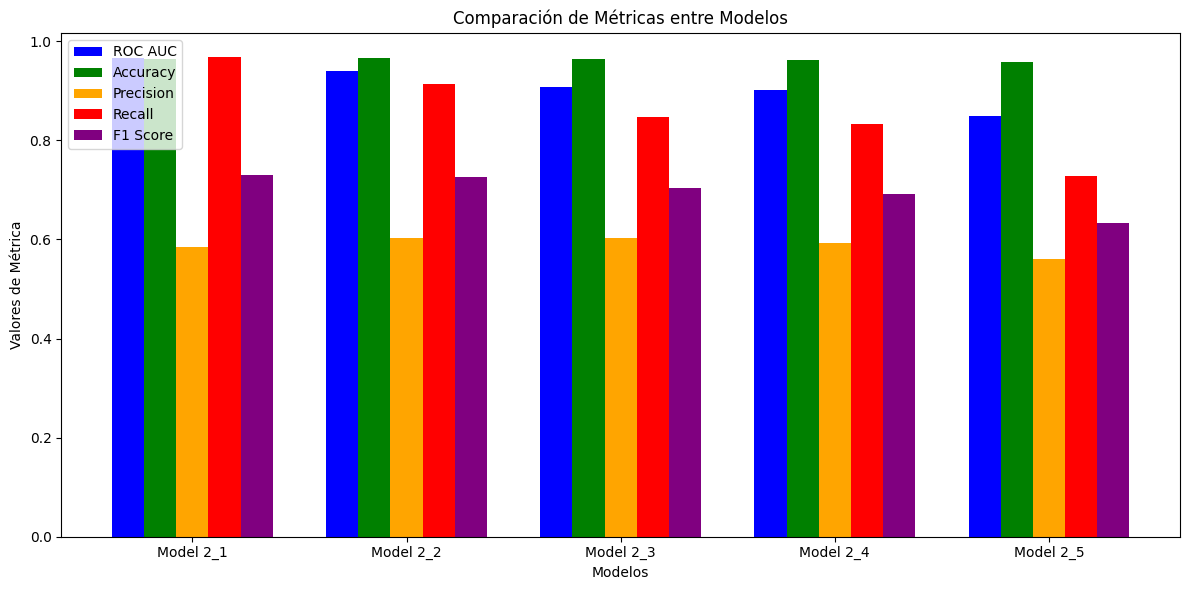

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de los modelos
model_names = ['Model 2_1', 'Model 2_2', 'Model 2_3', 'Model 2_4', 'Model 2_5']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m2_1_test, roc_auc_m2_2_test, roc_auc_m2_3_test, roc_auc_m2_4_test, roc_auc_m2_5_test]
accuracy = [accuracy_m2_1_test, accuracy_m2_2_test, accuracy_m2_3_test, accuracy_m2_4_test, accuracy_m2_5_test]
precision = [precision_m2_1_test, precision_m2_2_test, precision_m2_3_test, precision_m2_4_test, precision_m2_5_test]
recall = [recall_m2_1_test, recall_m2_2_test, recall_m2_3_test, recall_m2_4_test, recall_m2_5_test]
f1 = [f1_m2_1_test, f1_m2_2_test, f1_m2_3_test, f1_m2_4_test, f1_m2_5_test]

# Métricas y colores
metrics = [roc_auc, accuracy, precision, recall, f1]
metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['blue', 'green', 'orange', 'red', 'purple']

# Crear el gráfico de barras agrupadas
x = np.arange(len(model_names))  # Posiciones para los grupos
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar(x + i * bar_width, metric, width=bar_width, label=metric_names[i], color=color)

# Personalizar el gráfico
plt.xticks(x + 2 * bar_width, model_names)
plt.xlabel('Modelos')
plt.ylabel('Valores de Métrica')
plt.title('Comparación de Métricas entre Modelos')
plt.legend(loc='upper left')
plt.tight_layout()

# Mostrar el gráfico
plt.show()


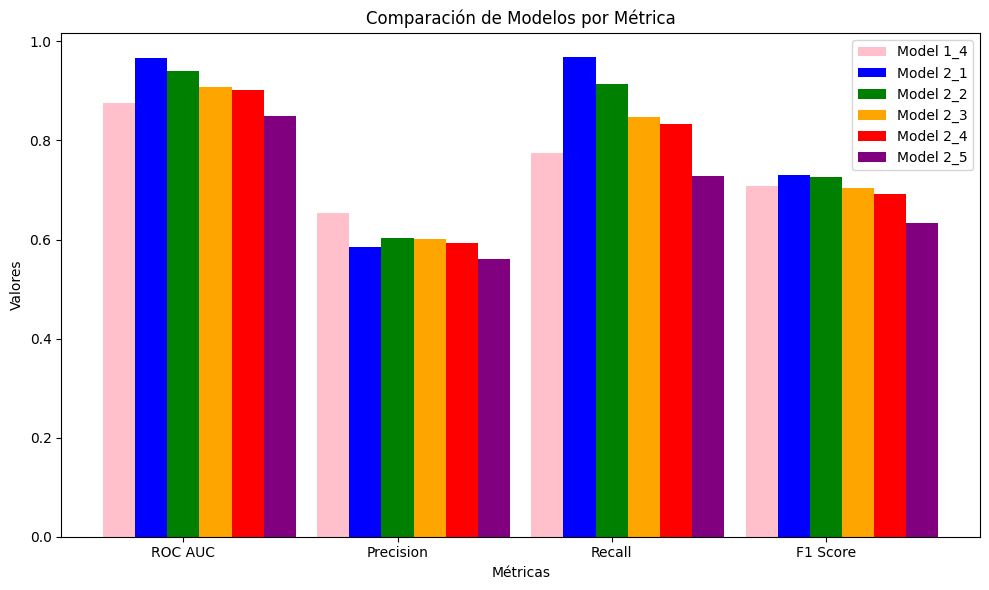

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['Model 1_4', 'Model 2_1', 'Model 2_2', 'Model 2_3', 'Model 2_4', 'Model 2_5']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_test, roc_auc_m2_1_test, roc_auc_m2_2_test, roc_auc_m2_3_test, roc_auc_m2_4_test, roc_auc_m2_5_test]
accuracy = [accuracy_m1_4_test, accuracy_m2_1_test, accuracy_m2_2_test, accuracy_m2_3_test, accuracy_m2_4_test, accuracy_m2_5_test]
precision = [precision_m1_4_test, precision_m2_1_test, precision_m2_2_test, precision_m2_3_test, precision_m2_4_test, precision_m2_5_test]
recall = [recall_m1_4_test, recall_m2_1_test, recall_m2_2_test, recall_m2_3_test, recall_m2_4_test, recall_m2_5_test]
f1 = [f1_m1_4_test, f1_m2_1_test, f1_m2_2_test, f1_m2_3_test, f1_m2_4_test, f1_m2_5_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue', 'green', 'orange', 'red', 'purple']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.title('Comparación de Modelos por Métrica')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()



## ~GNN + RNN (more features normalized - masks for nodes)~

In [ ]:
train_masks = []
for i in range(len(windows_input_train)):
  aux = []
  for j in range(4):
    aux.append(masks[i+j])
  train_masks.append()

25

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2 = EdgeClassificationModel_RNN_local(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out = model2(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out = model2(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



TypeError: EdgeClassificationModel_RNN_local.forward() missing 1 required positional argument: 'masks_nodes'

In [ ]:
suma_no0=0
for i in range(len(torch_geo_graphs_unsw1_proto_more_rnn[0].x)):
  if not (torch_geo_graphs_unsw1_proto_more_rnn[0].x[i,:]==0).all():
    suma_no0+=1

print(suma_no0)

4434


In [ ]:
suma_no0=0
for i in range(len(torch_geo_graphs_unsw1_proto_more[0].x)):
  if not (torch_geo_graphs_unsw1_proto_more[0].x[i,:]==0).all():
    suma_no0+=1

print(suma_no0)

4434


In [ ]:
len(torch_geo_graphs_unsw1_proto_more[0].x)

4451

In [ ]:
for i in range(len(torch_geo_graphs_unsw1_proto_more[0].x)):
  if (torch_geo_graphs_unsw1_proto_more[0].x[i,:]==0).all():
    print(i)


223
225
227
231
233
241
243
250
257
260
264
273
278
285
287
294
295


In [ ]:
print(unsw1['stime'].min())
print(unsw1['stime'].min() + timedelta(minutes=3))

2015-01-22 11:50:14
2015-01-22 11:53:14


In [ ]:
min_start_time = unsw1['stime'].min()



interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot


snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

src = snapshot_data[['srcip', 'sport','proto']].copy()
src.rename(columns={'srcip':'ip','sport':'port'}, inplace=True)

dst = snapshot_data[['dstip', 'dsport','proto']].copy()
dst.rename(columns={'dstip':'ip','dsport':'port'}, inplace=True)

unique_pairs = pd.concat([src,dst]).drop_duplicates()
unique_pairs['ip'] = unique_pairs['ip'].str.strip()
unique_pairs['port'] = unique_pairs['port'].astype(str).str.strip()
unique_pairs = unique_pairs.drop_duplicates(subset=['ip', 'port', 'proto'])

unique_pairs['pair_id'] = unique_pairs.groupby(['ip','port','proto']).ngroup()
unique_pairs = unique_pairs.sort_values('pair_id').set_index('pair_id').reset_index()
unique_pairs['pairs'] = unique_pairs.apply(lambda x: str(x['ip']) + ',' + str(x['port']) + ',' + str(x['proto']), axis=1)

pair_to_index = {pair: idx for idx, pair in zip(unique_pairs['pair_id'], unique_pairs['pairs'])}

In [ ]:
src_features1 = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean',
        'sbytes': 'mean',
        'sttl': 'mean',
        'sloss': 'mean',
        'sload': 'mean',
        'sjit': 'mean',
        'sintpkt': 'mean'
    }).reset_index()
src_features1['src_pairs'] = src_features1.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
src_features1 = src_features1.set_index('src_pairs').reindex(np.array(unique_pairs_list[0]['pairs']), fill_value=0).reset_index()
src_features1

,src_pairs,srcip,sport,proto,spkts,sbytes,sttl,sloss,sload,sjit,sintpkt
0,"149.171.126.0,10658,tcp",0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000
1,"149.171.126.0,10939,tcp",0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000
2,"149.171.126.0,111,udp",0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000
3,"149.171.126.0,11224,udp",0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000
4,"149.171.126.0,11399,tcp",0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
4446,"59.166.0.9,9307,tcp",59.166.0.9,9307,tcp,52.0,37268.0,31.0,18.0,4.127196e+06,91.587659,1.379843
4447,"59.166.0.9,9373,udp",59.166.0.9,9373,udp,4.0,520.0,31.0,0.0,8.663418e+03,162.630547,115.007664
4448,"59.166.0.9,9496,udp",59.166.0.9,9496,udp,2.0,130.0,31.0,0.0,5.194805e+05,0.000000,0.010000
4449,"59.166.0.9,9716,udp",59.166.0.9,9716,udp,2.0,132.0,31.0,0.0,4.911628e+05,0.000000,0.011000


In [ ]:
dst_features1 = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    'dpkts': 'mean',
    'dbytes': 'mean',
    'dttl': 'mean',
    'dloss': 'mean',
    'dload': 'mean',
    'djit': 'mean',
    'dintpkt': 'mean'
}).reset_index()
dst_features1['dst_pairs'] = dst_features1.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
dst_features1 = dst_features1.set_index('dst_pairs').reindex(np.array(unique_pairs_list[0]['pairs']), fill_value=0).reset_index()
dst_features1

,dst_pairs,dstip,dsport,proto,dpkts,dbytes,dttl,dloss,dload,djit,dintpkt
0,"149.171.126.0,10658,tcp",149.171.126.0,10658,tcp,70.0,59460.000000,29.0,28.0,1.071622e+07,36.091531,0.626116
1,"149.171.126.0,10939,tcp",149.171.126.0,10939,tcp,42.0,23162.000000,29.0,14.0,1.959490e+05,1646.760239,22.503806
2,"149.171.126.0,111,udp",149.171.126.0,111,udp,4.0,306.461538,29.0,0.0,3.332935e+05,7.743327,5.482436
3,"149.171.126.0,11224,udp",149.171.126.0,11224,udp,4.0,304.000000,29.0,0.0,9.470405e+05,0.382549,0.276000
4,"149.171.126.0,11399,tcp",149.171.126.0,11399,tcp,70.0,59460.000000,29.0,28.0,5.636758e+06,74.370179,1.198014
...,...,...,...,...,...,...,...,...,...,...,...
4446,"59.166.0.9,9307,tcp",0,0,0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000,0.000000
4447,"59.166.0.9,9373,udp",0,0,0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000,0.000000
4448,"59.166.0.9,9496,udp",0,0,0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000,0.000000
4449,"59.166.0.9,9716,udp",0,0,0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000,0.000000


In [ ]:
pair_to_index['149.171.126.0,10658,tcp']

60

In [ ]:
len(dst_features['dst_pairs'])

172471

In [ ]:
min_start_time = unsw1['stime'].min()

interval_snapshot = timedelta(minutes=3)
start_time = min_start_time
end_time = start_time  + interval_snapshot

snapshot_data = unsw1[(unsw1['stime'] >= start_time ) & (unsw1['stime'] < end_time)]

src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
    'spkts': 'mean',
    'sbytes': 'mean',
    'sttl': 'mean',
    'sloss': 'mean',
    'sload': 'mean',
    'sjit': 'mean',
    'sintpkt': 'mean'
}).reset_index()
src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs_list[0]['pairs']), fill_value=0).reset_index()

dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
    'dpkts': 'mean',
    'dbytes': 'mean',
    'dttl': 'mean',
    'dloss': 'mean',
    'dload': 'mean',
    'djit': 'mean',
    'dintpkt': 'mean'
}).reset_index()
dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs_list[0]['pairs']), fill_value=0).reset_index()

nodes_features = pd.merge(src_features, dst_features, left_on=['src_pairs'], right_on=['dst_pairs'], how='outer')
nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt', 'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
    'dur': 'mean',
    'synack': 'mean',
    'ackdat': 'mean',
    'label': 'max'
}).reset_index()
edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

edge_index = torch.tensor([[pair_to_index_list[0][src], pair_to_index_list[0][dst]] for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])], dtype=torch.long).t().contiguous()

edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)


In [ ]:
len(src_features)

4451

In [ ]:
unique_pairs_list[0]

,pair_id,ip,port,proto,pairs
0,0,149.171.126.0,10658,tcp,"149.171.126.0,10658,tcp"
1,1,149.171.126.0,10939,tcp,"149.171.126.0,10939,tcp"
2,2,149.171.126.0,111,udp,"149.171.126.0,111,udp"
3,3,149.171.126.0,11224,udp,"149.171.126.0,11224,udp"
4,4,149.171.126.0,11399,tcp,"149.171.126.0,11399,tcp"
...,...,...,...,...,...
4446,4446,59.166.0.9,9307,tcp,"59.166.0.9,9307,tcp"
4447,4447,59.166.0.9,9373,udp,"59.166.0.9,9373,udp"
4448,4448,59.166.0.9,9496,udp,"59.166.0.9,9496,udp"
4449,4449,59.166.0.9,9716,udp,"59.166.0.9,9716,udp"


In [ ]:
pair_to_index_list[0]['149.171.126.0,11922,tcp']

6

In [ ]:
pair_to_index['149.171.126.0,11922,tcp']

154

In [ ]:
unique_pairs_list[0].iloc[6,:]

,6
pair_id,6
ip,149.171.126.0
port,11922
proto,tcp
pairs,"149.171.126.0,11922,tcp"


In [ ]:
unique_pairs_list[1].iloc[5,:]

,5
pair_id,5
ip,149.171.126.0
port,11922
proto,tcp
pairs,"149.171.126.0,11922,tcp"


In [ ]:
torch_geo_graphs_unsw1_proto_more_rnn_local[0].x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
len(masks[0])

4451

In [ ]:
torch_geo_graphs_unsw1_proto_more_rnn_local[0].x[masks[0],:]

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.0716e+07, 3.6092e+01,
         6.2612e-01],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.9595e+05, 1.6468e+03,
         2.2504e+01],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.3329e+05, 7.7433e+00,
         5.4824e+00],
        ...,
        [2.0000e+00, 1.3000e+02, 3.1000e+01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.0000e+00, 1.3200e+02, 3.1000e+01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.0000e+00, 1.4600e+02, 3.1000e+01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])

In [ ]:
for i in range(len(torch_geo_graphs_unsw1_proto_more_rnn_local[0].x[masks[0],:])):
  if (torch_geo_graphs_unsw1_proto_more_rnn_local[0].x[masks[0],:][i,:]==0).all():
    print(i)

223
225
227
231
233
241
243
250
257
260
264
273
278
285
287
294
295


In [ ]:
for i in range(len(torch_geo_graphs_unsw1_proto_more[0].x)):
  if (torch_geo_graphs_unsw1_proto_more[0].x[i,:]==0).all():
    print(i)

223
225
227
231
233
241
243
250
257
260
264
273
278
285
287
294
295


## RNN without features

In [ ]:
num_nodes = torch_geo_graphs_unsw1_proto_more_rnn[0].x.size(0)
embedding_dim = 8   # Dimensión de los embeddings de nodos

node_embeddings = nn.Embedding(num_nodes, embedding_dim)


hidden_size_gru = 16     # Dimensión del estado oculto de la RNN
model3 = GraphEdgeRNN(input_dim=2*embedding_dim, hidden_size_gru=16)#, seq_len=4)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)




# Train
epochs = 150
train_losses_m3 = []
val_losses_m3 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model3.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out = model3(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m3.append(train_loss)

    # ===== Validation =====
    model3.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m3, all_labels_m3 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out = model3(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m3.extend(preds)
            all_labels_m3.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m3.append(val_loss_final)
    roc_auc_m3 = roc_auc_score(all_labels_m3, all_preds_m3)
    f1_m3 = f1_score(all_labels_m3, all_preds_m3, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m3)

    #print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, ROC-AUC: {roc_auc_m3}, F1:{f1_m3}")
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m3}, F1:{f1_m3}")


Epoch 1/150, Train Loss: 0.3932, Val Loss: 0.1891, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/150, Train Loss: 0.2073, Val Loss: 0.1931, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 3/150, Train Loss: 0.1988, Val Loss: 0.1891, Current LR: 0.010000, ROC-AUC: 0.4999411175881764, F1:0.0
Epoch 4/150, Train Loss: 0.1871, Val Loss: 0.1865, Current LR: 0.010000, ROC-AUC: 0.500461922368616, F1:0.002531645569620253
Epoch 5/150, Train Loss: 0.1726, Val Loss: 0.1768, Current LR: 0.010000, ROC-AUC: 0.5025745826962865, F1:0.012360939431396786
Epoch 6/150, Train Loss: 0.1601, Val Loss: 0.1634, Current LR: 0.010000, ROC-AUC: 0.5056496658930737, F1:0.02444987775061125
Epoch 7/150, Train Loss: 0.1504, Val Loss: 0.1518, Current LR: 0.010000, ROC-AUC: 0.5072709626462162, F1:0.031287605294825514
Epoch 8/150, Train Loss: 0.1420, Val Loss: 0.1419, Current LR: 0.010000, ROC-AUC: 0.5167611830897835, F1:0.06595995288574794
Epoch 9/150, Train Loss: 0.1347, Val Loss: 0.1337, Current LR: 0.010000, ROC

KeyboardInterrupt: 